# 02 — Exploratory Data Analysis

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**  
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 1.1

---

## Objectives

Explore and validate all collected data before modelling:

1. **Price distributions** — log returns, volatility regimes, stationarity tests (ADF)
2. **VIX and macro co-movement** — correlation with asset returns across regimes
3. **Presidential document EDA** — document counts by type, year, and president
4. **FOMC event density** — meeting frequency and rate change distribution
5. **Missing data audit** — gaps, coverage, trading-day alignment
6. **Event frequency analysis** — event counts by category over 2015–2025

Outputs: exploratory charts saved to `reports/figures/`.


In [23]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# --- Project src imports ---
from src.data_collector import load_config

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})
PALETTE = {'SPY': '#2196F3', 'QQQ': '#FF5722', 'GLD': '#FFC107', 'TLT': '#4CAF50'}
FIG_DIR = '../reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

## Load project config

In [25]:
from pathlib import Path

# ==========================================================
# Load Project Configuration
# ==========================================================

config = load_config("../config.yaml")

print(f"Config loaded: {config['project']['name']}")

# ==========================================================
# Standard Project Paths
# ==========================================================

PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"
STAT_DIR = REPORT_DIR / "statistics"

# Create report folders if they don't exist
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
STAT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project Root : {PROJECT_ROOT}")
print(f"Figures      : {FIG_DIR}")
print(f"Tables       : {TABLE_DIR}")
print(f"Statistics   : {STAT_DIR}")

Config loaded: Causal Event-Driven Market Impact Modelling
Project Root : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI
Figures      : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures
Tables       : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/tables
Statistics   : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/statistics


---
## 1. Load All Datasets

Load all parquet files produced by `01_data_collection.ipynb`.

In [26]:
RAW = config['paths']['data_raw']

def load_time_indexed_parquet(path, date_col="date"):
    df = pd.read_parquet(path)

    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
    else:
        df.index = pd.to_datetime(df.index)

    df = df.sort_index()
    return df


# --- Prices ---
prices    = load_time_indexed_parquet(f'{RAW}/prices.parquet')
spy_ohlcv = load_time_indexed_parquet(f'{RAW}/spy_ohlcv.parquet')
vix       = load_time_indexed_parquet(f'{RAW}/vix.parquet')

# --- Keep only numeric columns for market calculations ---
prices = prices.apply(pd.to_numeric, errors="coerce")
spy_ohlcv = spy_ohlcv.apply(pd.to_numeric, errors="coerce")
vix = vix.apply(pd.to_numeric, errors="coerce")

# --- Macro ---
macro = pd.read_parquet(f'{RAW}/macro_indicators.parquet')

# --- Events ---
fomc     = pd.read_parquet(f'{RAW}/fomc_dates.parquet')
app_docs = pd.read_parquet(f'{RAW}/app_presidential_documents.parquet')
gdelt    = pd.read_parquet(f'{RAW}/gdelt_sample.parquet')

# --- Align VIX to prices index ---
vix = vix.reindex(prices.index, method='ffill')

# --- Log returns ---
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f"Prices        : {prices.shape[0]:,} rows × {prices.shape[1]} tickers  ({prices.index[0].date()} → {prices.index[-1].date()})")
print(f"Log returns   : {log_returns.shape[0]:,} rows")
print(f"VIX           : {vix.shape[0]:,} rows | mean={vix.iloc[:,0].mean():.2f}")
print(f"Macro         : {macro.shape[0]:,} rows × {macro.shape[1]} indicators")
print(f"FOMC events   : {len(fomc):,}")
print(f"APP documents : {len(app_docs):,} (presidential communications 2015–2025)")
print(f"GDELT sample  : {len(gdelt):,} events")


Prices        : 2,765 rows × 4 tickers  (2015-01-02 → 2025-12-30)
Log returns   : 2,764 rows
VIX           : 2,765 rows | mean=18.33
Macro         : 2,870 rows × 7 indicators
FOMC events   : 89
APP documents : 11,629 (presidential communications 2015–2025)
GDELT sample  : 2,405 events


---
## 2. Price & Returns EDA

### 2a. Normalised Price Trajectories (Jan 2015 = 100)


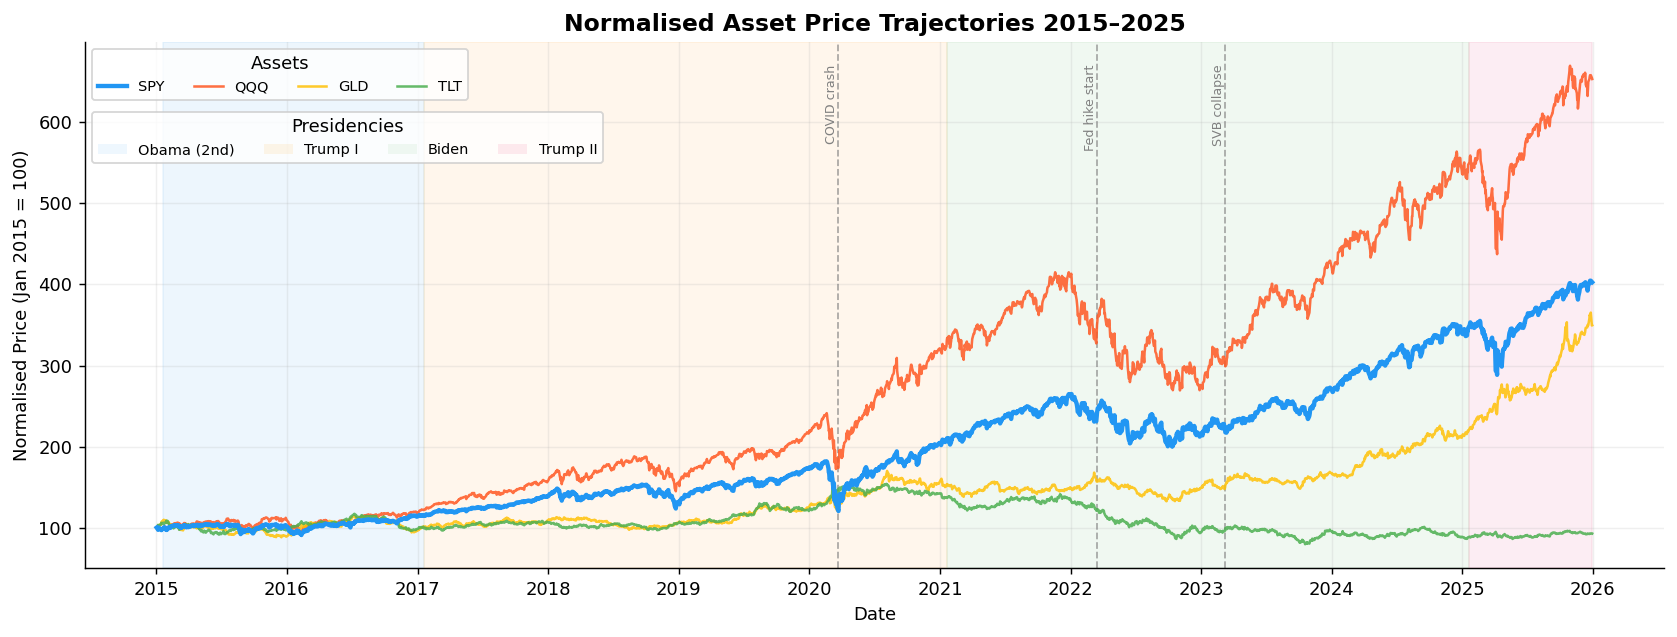

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02a_normalised_prices.png


In [27]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(13, 5))
normed = (prices / prices.iloc[0]) * 100

# --- Shade presidencies first so lines stay visible ---
pres_bands = [
    ('2015-01-20', '2017-01-20', 'Obama (2nd)', '#90CAF9', 0.15),
    ('2017-01-20', '2021-01-20', 'Trump I',     '#FFCC80', 0.18),
    ('2021-01-20', '2025-01-20', 'Biden',       '#A5D6A7', 0.15),
    ('2025-01-20', '2025-12-31', 'Trump II',    '#F48FB1', 0.18),
]

for start, end, _, color, _ in pres_bands:
    start_dt = pd.Timestamp(start)
    end_dt = min(pd.Timestamp(end), prices.index[-1])

    ax.axvspan(start_dt, end_dt,
               color=color,
               alpha=0.10,
               zorder=0)

    ax.axvspan(start_dt, end_dt,
               color=color,
               alpha=0.05,
               zorder=0)

# --- Plot assets with SPY as benchmark focus ---
asset_order = ['SPY', 'QQQ', 'GLD', 'TLT']

for ticker in asset_order:
    if ticker not in normed.columns:
        continue

    if ticker == "SPY":
        linewidth = 2.4
        alpha = 1.0
        zorder = 4
    else:
        linewidth = 1.4
        alpha = 0.85
        zorder = 3

    ax.plot(
        normed.index,
        normed[ticker],
        label=ticker,
        color=PALETTE.get(ticker, 'grey'),
        linewidth=linewidth,
        alpha=alpha,
        zorder=zorder
    )

# --- Key event markers ---
events = {
    "2020-03-23": "COVID crash",
    "2022-03-16": "Fed hike start",
    "2023-03-10": "SVB collapse",
}

for date_str, label in events.items():
    event_date = pd.Timestamp(date_str)
    if prices.index.min() <= event_date <= prices.index.max():
        ax.axvline(
            event_date,
            color="grey",
            linestyle="--",
            linewidth=1,
            alpha=0.65,
            zorder=2
        )
        ax.text(
            event_date,
            ax.get_ylim()[1] * 0.96,
            label,
            rotation=90,
            fontsize=7,
            color="grey",
            va="top",
            ha="right"
        )

# --- Presidency labels as separate legend patches ---
pres_handles = [
    Patch(facecolor=color, alpha=alpha, label=label)
    for _, _, label, color, alpha in pres_bands
]

asset_legend = ax.legend(
    title="Assets",
    loc="upper left",
    ncol=4,
    fontsize=8,
    frameon=True
)

ax.add_artist(asset_legend)

ax.legend(
    handles=pres_handles,
    title="Presidencies",
    loc="upper left",
    bbox_to_anchor=(0, 0.88),
    ncol=4,
    fontsize=8,
    frameon=True
)

# --- Labels and formatting ---
ax.set_xlabel('Date')
ax.set_ylabel('Normalised Price (Jan 2015 = 100)')
ax.set_title(
    'Normalised Asset Price Trajectories 2015–2025',
    fontsize=13,
    fontweight='bold'
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02a_normalised_prices.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved → {FIG_DIR}/02a_normalised_prices.png")

### 2b. Log-Return Distributions

Histograms with Normal overlay — assess fat tails and skewness.

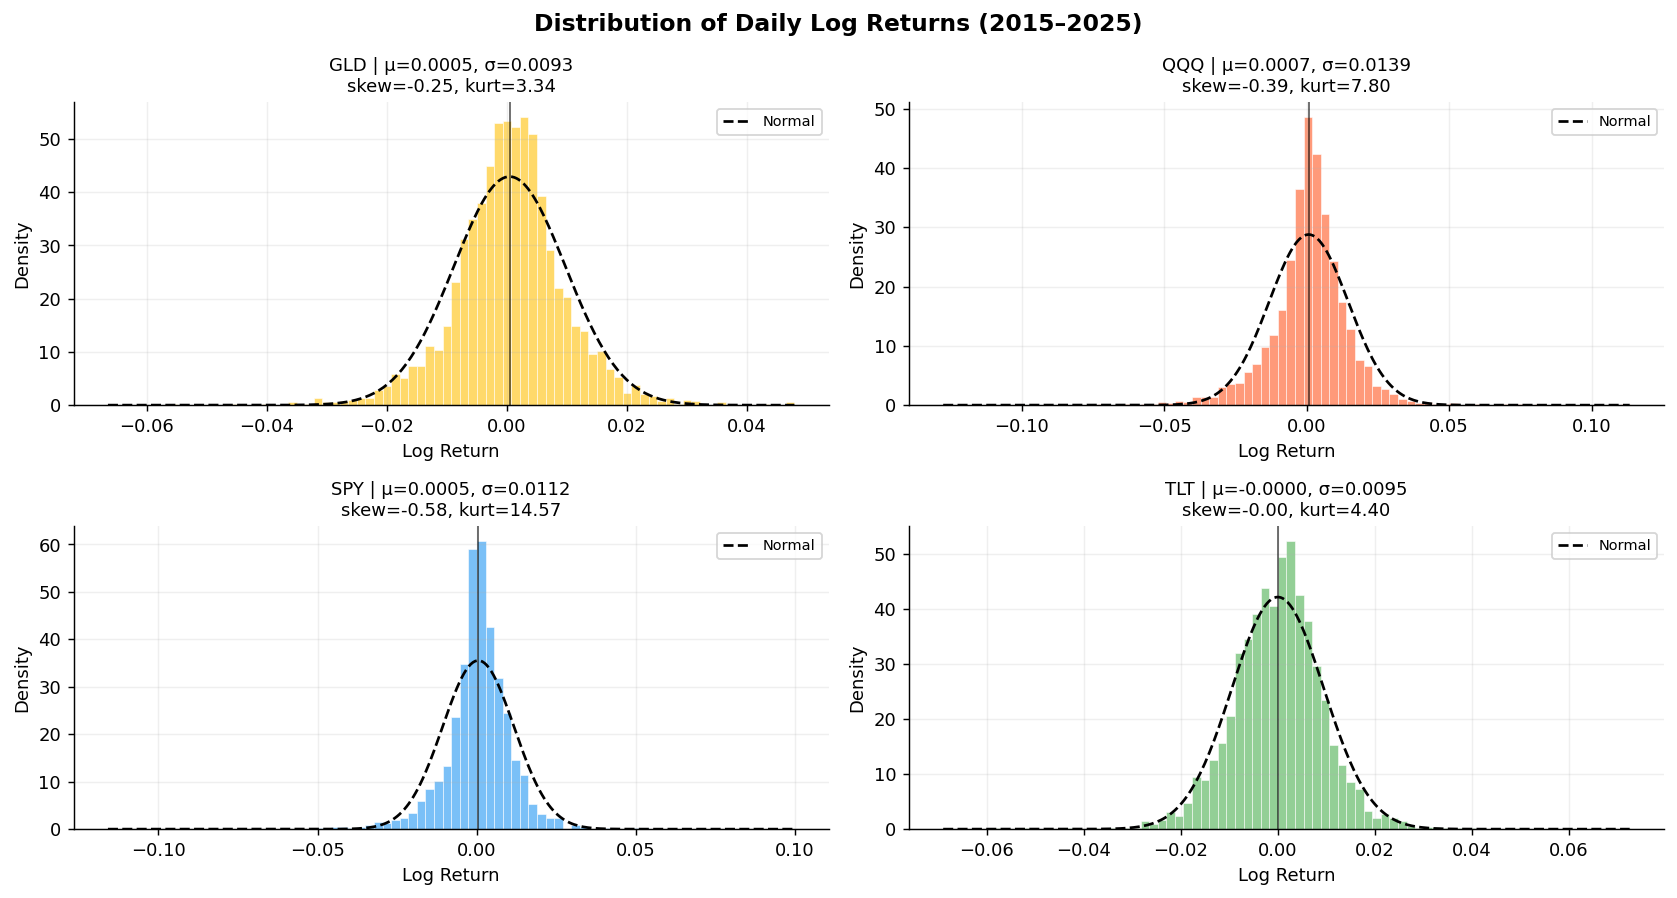

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02b_return_distributions.png


In [28]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

for ax, ticker in zip(axes, log_returns.columns):
    r = log_returns[ticker].dropna()

    # --- Histogram ---
    ax.hist(
        r,
        bins=80,
        density=True,
        alpha=0.6,
        color=PALETTE.get(ticker, 'grey'),
        edgecolor='white',
        linewidth=0.5
    )

    # --- Normal distribution overlay ---
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(
        x,
        stats.norm.pdf(x, r.mean(), r.std()),
        linestyle='--',
        color='black',
        linewidth=1.5,
        label='Normal'
    )

    # --- Mean line ---
    ax.axvline(
        r.mean(),
        color='black',
        linestyle='-',
        linewidth=1,
        alpha=0.6
    )

    # --- Title with key stats ---
    ax.set_title(
        f"{ticker} | μ={r.mean():.4f}, σ={r.std():.4f}\n"
        f"skew={r.skew():.2f}, kurt={r.kurtosis():.2f}",
        fontsize=10
    )

    ax.set_xlabel('Log Return')
    ax.set_ylabel('Density')
    ax.grid(alpha=0.2)

    ax.legend(fontsize=8)

# --- Global title ---
fig.suptitle(
    'Distribution of Daily Log Returns (2015–2025)',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02b_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved → {FIG_DIR}/02b_return_distributions.png")

### 2c. Rolling Volatility (30-day)

Highlights volatility regimes (COVID crash, Trump-era shocks).

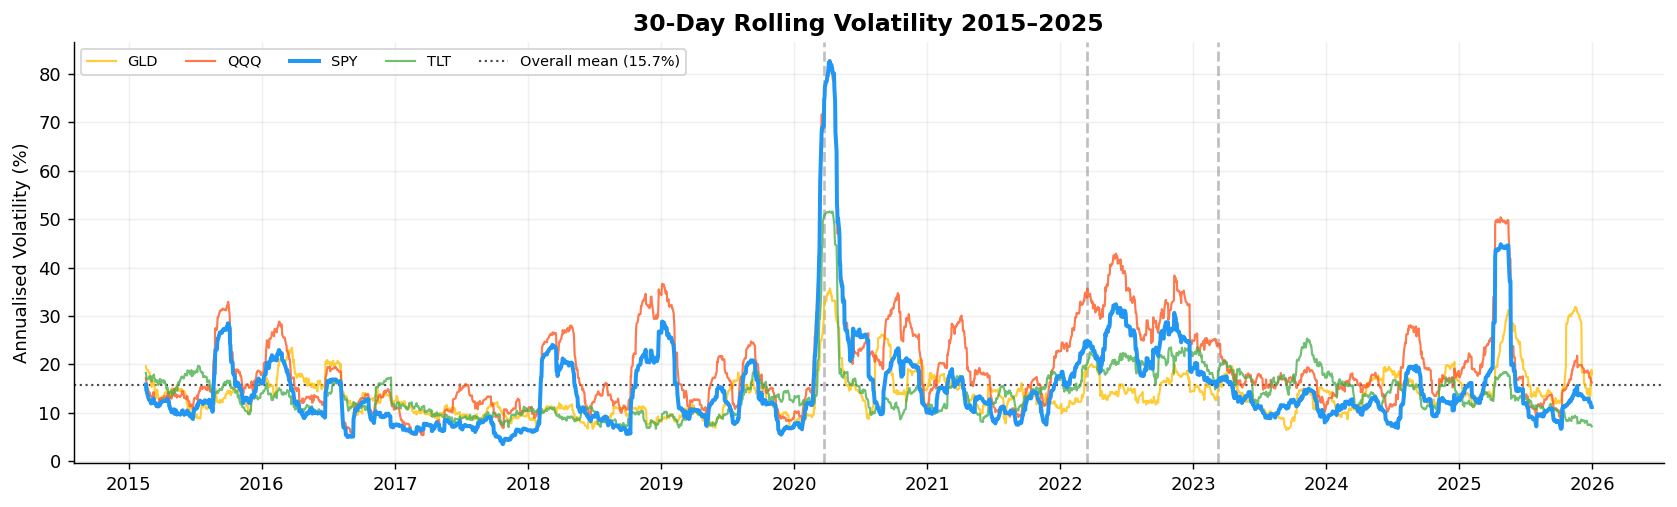

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02c_rolling_volatility.png


In [29]:
roll_vol = log_returns.rolling(30).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(13, 4))

for ticker in roll_vol.columns:
    if ticker == "SPY":
        lw, alpha, z = 2.2, 1.0, 4
    else:
        lw, alpha, z = 1.2, 0.8, 3

    ax.plot(
        roll_vol.index,
        roll_vol[ticker],
        label=ticker,
        color=PALETTE.get(ticker, 'grey'),
        linewidth=lw,
        alpha=alpha,
        zorder=z
    )

# --- Mean line ---
mean_vol = roll_vol.stack().mean()
ax.axhline(
    mean_vol,
    color='black',
    linestyle=':',
    linewidth=1.2,
    alpha=0.7,
    label=f'Overall mean ({mean_vol:.1f}%)'
)

# --- Event markers ---
events = {
    "2020-03-23": "COVID",
    "2022-03-16": "Fed hikes",
    "2023-03-10": "SVB",
}

for d, label in events.items():
    dt = pd.Timestamp(d)
    if roll_vol.index.min() <= dt <= roll_vol.index.max():
        ax.axvline(dt, color='grey', linestyle='--', alpha=0.5)

# --- Formatting ---
ax.set_ylabel('Annualised Volatility (%)')
ax.set_title('30-Day Rolling Volatility 2015–2025', fontsize=13, fontweight='bold')

ax.legend(ncol=5, fontsize=8)
ax.grid(alpha=0.2)

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02c_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved → {FIG_DIR}/02c_rolling_volatility.png")

### 2d. Augmented Dickey-Fuller Stationarity Tests

Confirm log-returns are stationary (required for modelling).

In [30]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

print(f"{'Ticker':<6} {'ADF Stat':>10} {'ADF p':>10} {'ADF Lags':>9} "
      f"{'KPSS Stat':>10} {'KPSS p':>10} {'KPSS Lags':>10} {'Stationary?':>14}")
print("-" * 90)

for ticker in log_returns.columns:
    r = log_returns[ticker].dropna()

    # --- ADF test ---
    # H0: series has a unit root (non-stationary)
    adf_stat, adf_p, adf_lags, _, adf_crit, _ = adfuller(r, autolag="AIC")

    # --- KPSS test ---
    # H0: series is stationary
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(
            r,
            regression="c",
            nlags="auto"
        )

    # --- Combined decision ---
    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p > 0.05

    if adf_stationary and kpss_stationary:
        stationary = "✓ Yes"
    elif adf_stationary and not kpss_stationary:
        stationary = "Mixed"
    else:
        stationary = "✗ No"

    print(
        f"{ticker:<6} "
        f"{adf_stat:>10.4f} {adf_p:>10.4f} {adf_lags:>9} "
        f"{kpss_stat:>10.4f} {kpss_p:>10.4f} {kpss_lags:>10} "
        f"{stationary:>14}"
    )

Ticker   ADF Stat      ADF p  ADF Lags  KPSS Stat     KPSS p  KPSS Lags    Stationary?
------------------------------------------------------------------------------------------
GLD      -52.5156     0.0000         0     0.4943     0.0430          6          Mixed
QQQ      -17.5056     0.0000         8     0.0425     0.1000          9          ✓ Yes
SPY      -17.0317     0.0000         8     0.0556     0.1000          6          ✓ Yes
TLT      -10.0722     0.0000        24     0.1535     0.1000          6          ✓ Yes


**Interpretation:**
Interpretation:
ADF test:
- `H0` = the series has a unit root, meaning it is non-stationary.
- `p < 0.05` means reject `H0`, supporting stationarity.

KPSS test:
- `H0` = the series is stationary.
- `p > 0.05` means fail to reject `H0`, supporting stationarity.

A series is treated as robustly stationary when ADF rejects non-stationarity
and KPSS does not reject stationarity.

“Augmented Dickey-Fuller (ADF) and KPSS tests were applied to assess the stationarity of log return series. While all assets reject the unit root hypothesis under the ADF test (p < 0.05), the KPSS test provides additional validation by testing the null of stationarity. Results indicate that equity indices (SPY, QQQ) and bonds (TLT) are robustly stationary across both tests. However, gold (GLD) exhibits mixed results, reflecting potential regime-dependent behaviour or structural persistence. Overall, the findings support the use of log returns for subsequent modelling within the framework.”

---
## 3. VIX & Macro Indicators

### 3a. VIX Over Time with Threshold Bands


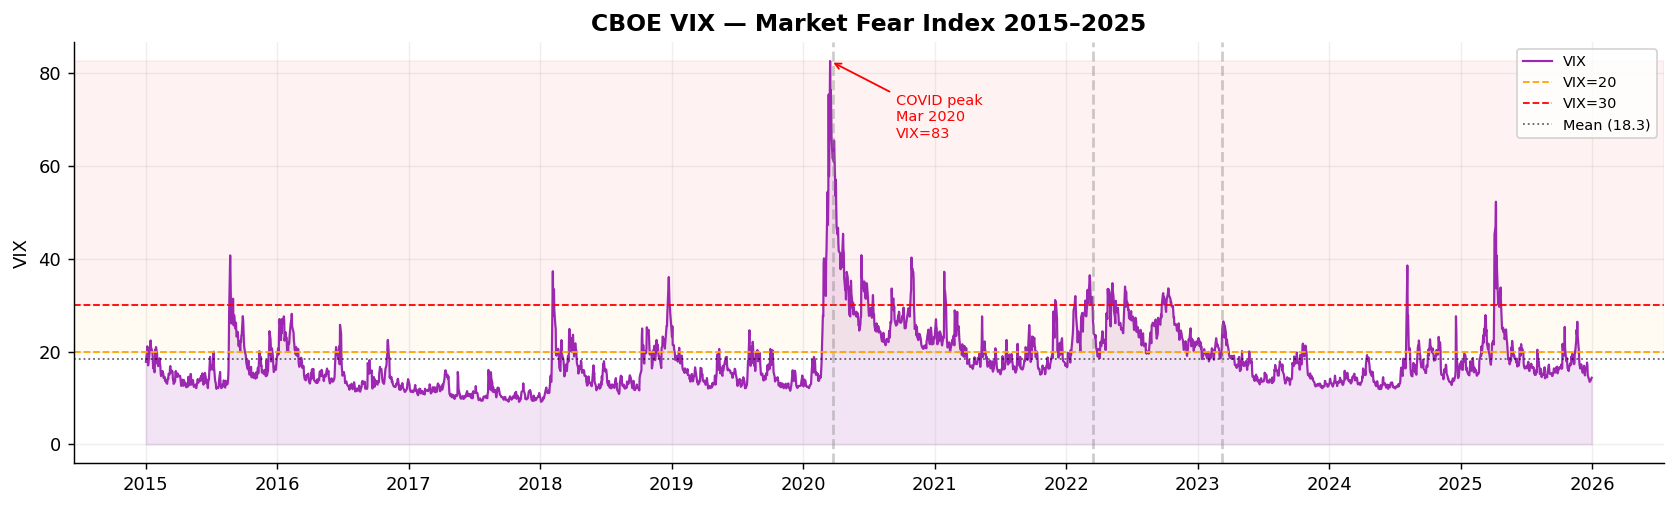

VIX > 30: 5.6% of trading days
Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02d_vix_series.png


In [31]:
fig, ax = plt.subplots(figsize=(13, 4))
vix_series = vix.iloc[:, 0]

# --- Main series ---
ax.plot(vix.index, vix_series, color='#9C27B0', linewidth=1.2, label='VIX')
ax.fill_between(vix.index, vix_series, alpha=0.12, color='#9C27B0')

# --- Stress zones ---
ax.axhspan(20, 30, color='orange', alpha=0.05)
ax.axhspan(30, vix_series.max(), color='red', alpha=0.05)

# --- Threshold lines ---
ax.axhline(20, color='orange', linestyle='--', linewidth=1, label='VIX=20')
ax.axhline(30, color='red', linestyle='--', linewidth=1, label='VIX=30')

# --- Mean line ---
mean_vix = vix_series.mean()
ax.axhline(mean_vix, color='black', linestyle=':', linewidth=1,
           alpha=0.6, label=f'Mean ({mean_vix:.1f})')

# --- Event markers ---
events = {
    "2020-03-23": "COVID",
    "2022-03-16": "Fed hikes",
    "2023-03-10": "SVB"
}

for d, label in events.items():
    dt = pd.Timestamp(d)
    if vix.index.min() <= dt <= vix.index.max():
        ax.axvline(dt, color='grey', linestyle='--', alpha=0.4)

# --- Peak annotation ---
peak_date = vix_series.idxmax()

ax.annotate(
    f'COVID peak\n{peak_date.strftime("%b %Y")}\nVIX={vix_series.max():.0f}',
    xy=(peak_date, vix_series.max()),
    xytext=(peak_date + pd.DateOffset(months=6), vix_series.max() * 0.8),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=8,
    color='red'
)

# --- Formatting ---
ax.set_ylabel('VIX')
ax.set_title('CBOE VIX — Market Fear Index 2015–2025', fontsize=13, fontweight='bold')

import matplotlib.dates as mdates
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.legend(fontsize=8)
ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02d_vix_series.png', dpi=150, bbox_inches='tight')
plt.show()

high_vix_pct = (vix_series > 30).mean() * 100
print(f"VIX > 30: {high_vix_pct:.1f}% of trading days")
print(f"Saved → {FIG_DIR}/02d_vix_series.png")

### 3b. Macro Indicators Over Time

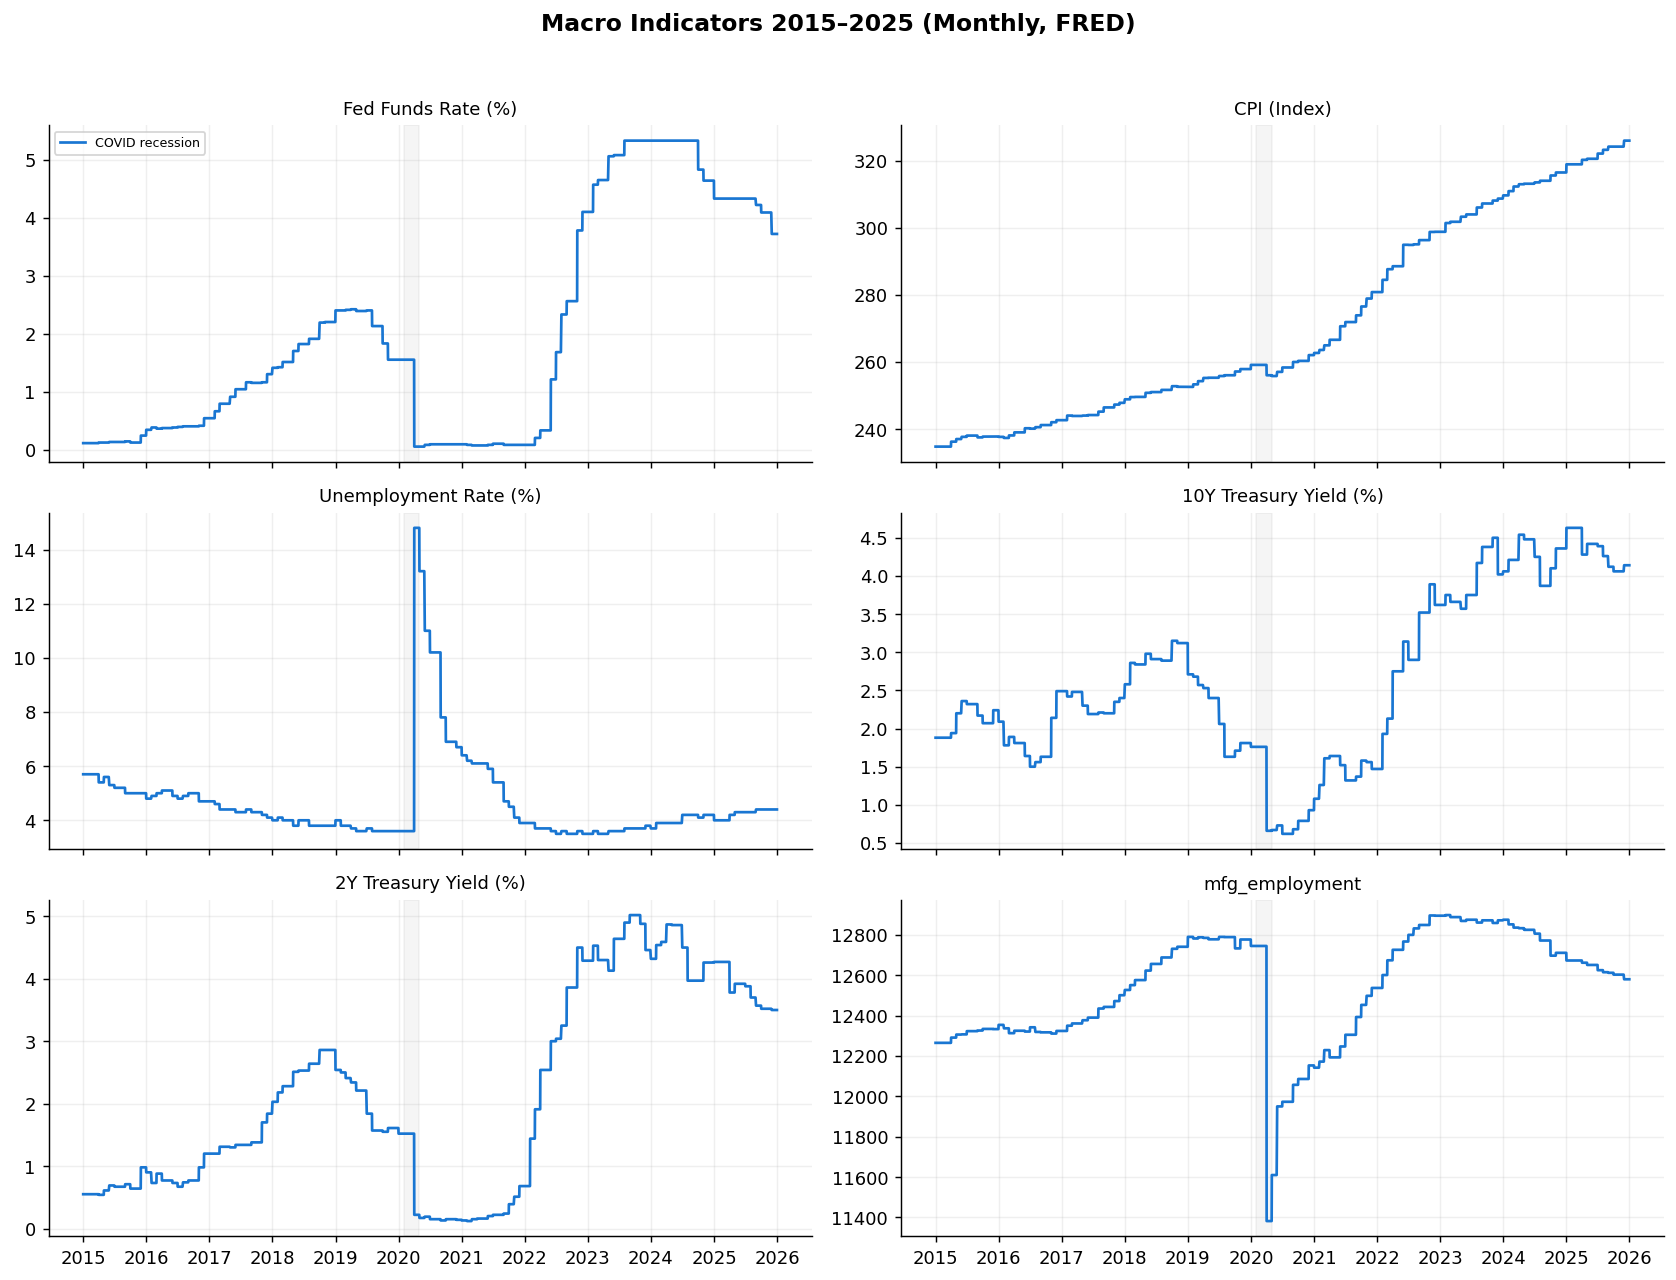

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02e_macro_indicators.png


In [32]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
axes = axes.flatten()

title_map = {
    'fed_funds_rate': 'Fed Funds Rate (%)',
    'cpi': 'CPI (Index)',
    'unemployment': 'Unemployment Rate (%)',
    'treasury_10y': '10Y Treasury Yield (%)',
    'treasury_2y': '2Y Treasury Yield (%)',
    'yield_spread': 'Yield Spread (10Y–2Y)'
}

macro_index = pd.to_datetime(macro.index)

for i, col in enumerate(macro.columns[:6]):
    ax = axes[i]

    ax.plot(macro_index, macro[col], color='#1976D2', linewidth=1.5)

    ax.set_title(title_map.get(col, col), fontsize=10)
    ax.set_ylabel('')
    ax.grid(alpha=0.2)

    # Yield spread zero line
    if col == 'yield_spread':
        ax.axhline(0, color='black', linestyle='--', linewidth=1)

    # COVID shading
    ax.axvspan(
        pd.Timestamp('2020-02-01'),
        pd.Timestamp('2020-04-30'),
        alpha=0.08,
        color='grey'
    )

    # Format x-axis
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Legend only once
axes[0].legend(['COVID recession'], fontsize=7)

fig.suptitle(
    'Macro Indicators 2015–2025 (Monthly, FRED)',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(f'{FIG_DIR}/02e_macro_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved → {FIG_DIR}/02e_macro_indicators.png")

“The macroeconomic environment underwent a structural shift post-2020, characterised by near-zero interest rates, a sharp rise in unemployment, and subsequent inflation-driven monetary tightening. The inversion of the yield curve in 2022–2023 further signals recessionary expectations. These macro dynamics provide critical context for understanding market responses to political and policy decisions within the GOVFIN framework.”

### 3c. Asset Returns vs VIX Correlation Heatmap

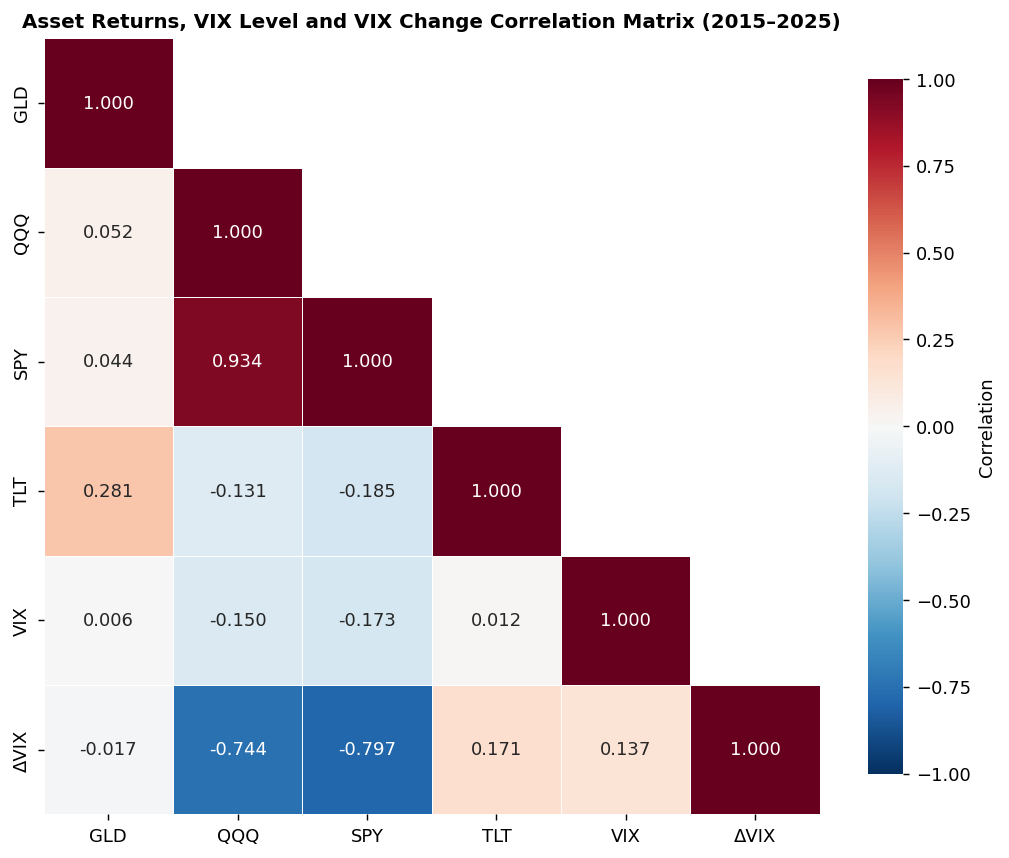

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02f_return_vix_corr.png


In [33]:
# Align returns and VIX on same index
vix_daily = vix.iloc[:, 0].rename('VIX')
vix_change = vix_daily.diff().rename('ΔVIX')

combined = log_returns.join([vix_daily, vix_change], how='inner').dropna()

corr = combined.corr()

fig, ax = plt.subplots(figsize=(8, 7))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'}
)

ax.set_title(
    'Asset Returns, VIX Level and VIX Change Correlation Matrix (2015–2025)',
    fontsize=11,
    fontweight='bold'
)

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02f_return_vix_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved → {FIG_DIR}/02f_return_vix_corr.png")

“The correlation analysis reveals a strong negative relationship between equity returns and changes in the VIX (ΔVIX), particularly for SPY (-0.797) and QQQ (-0.744). This indicates that sudden increases in market uncertainty are associated with significant declines in equity prices. In contrast, the level of the VIX exhibits only weak correlations with returns, suggesting that markets respond more strongly to changes in perceived risk rather than its absolute level. These findings support the event-driven nature of the GOVFIN framework.”

---
## 4. Presidential Communications EDA (APP)

### 4a. Document Counts by Type and Year


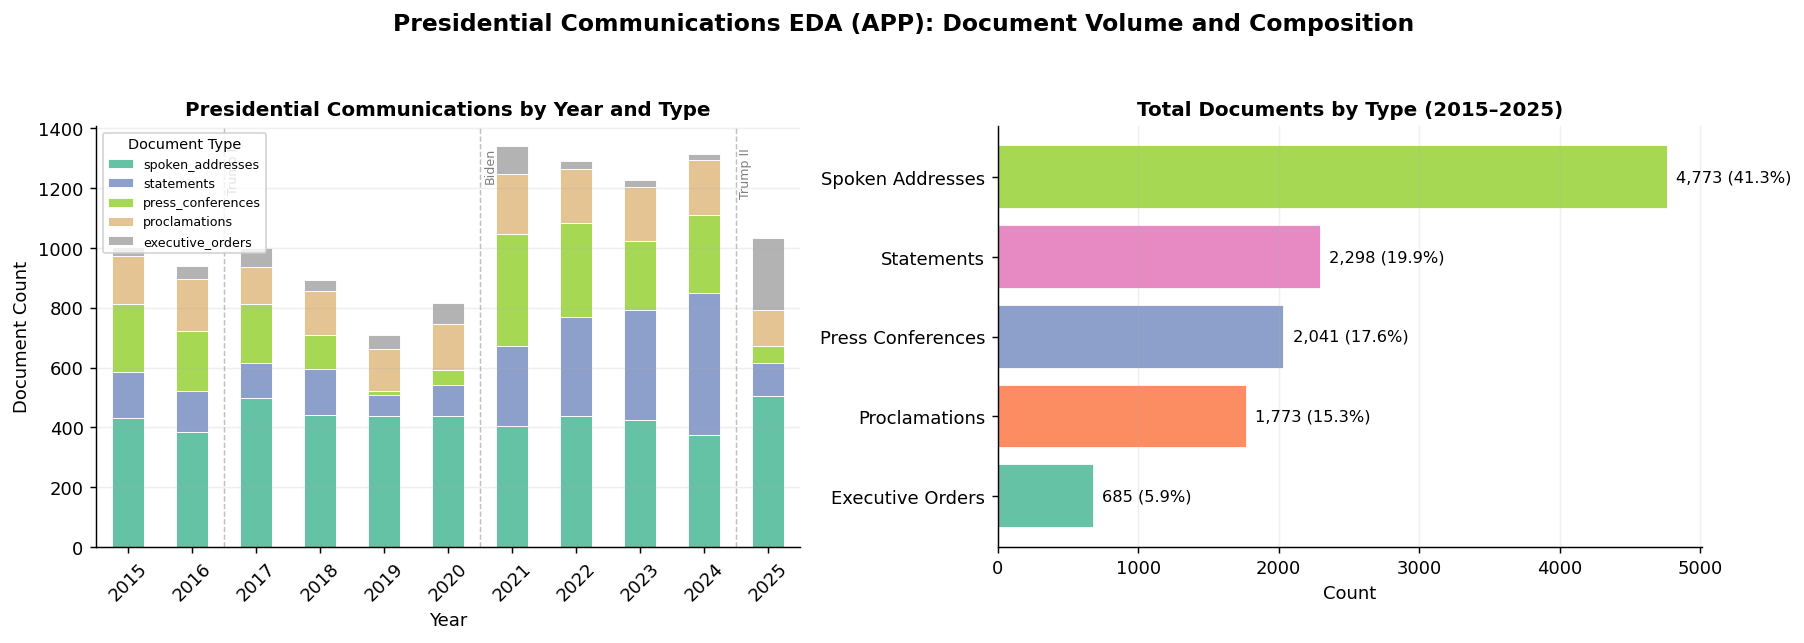

Total documents (core presidents): 11,570

Documents by type:
doc_type
spoken_addresses     4773
statements           2298
press_conferences    2041
proclamations        1773
executive_orders      685

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02g_app_doc_distribution.png


In [34]:
app_docs['date'] = pd.to_datetime(app_docs['date'])
app_docs['year'] = app_docs['date'].dt.year

# --- Filter to core presidents only ---
core_presidents = [
    'Barack Obama',
    'Donald J. Trump (1st Term)',
    'Joseph R. Biden, Jr.',
    'Donald J. Trump (2nd Term)'
]

app_main = app_docs[app_docs['president'].isin(core_presidents)].copy()

# --- Pivot: year × document type ---
pivot = (
    app_main
    .groupby(['year', 'doc_type'])
    .size()
    .unstack(fill_value=0)
)

# Consistent document order
doc_order = [
    'spoken_addresses',
    'statements',
    'press_conferences',
    'proclamations',
    'executive_orders'
]

pivot = pivot[[c for c in doc_order if c in pivot.columns]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================
# Left: stacked bar by year
# ============================================================
pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='Set2',
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_title('Presidential Communications by Year and Type', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Document Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.2)

axes[0].legend(
    title='Document Type',
    fontsize=7,
    title_fontsize=8,
    loc='upper left'
)

# Optional election / transition markers
for year, label in {
    2017: 'Trump I',
    2021: 'Biden',
    2025: 'Trump II'
}.items():
    if year in pivot.index:
        xpos = list(pivot.index).index(year)
        axes[0].axvline(xpos - 0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
        axes[0].text(
            xpos - 0.45,
            axes[0].get_ylim()[1] * 0.95,
            label,
            rotation=90,
            fontsize=7,
            color='grey',
            va='top'
        )

# ============================================================
# Right: total by document type
# ============================================================
doc_totals = app_main['doc_type'].value_counts()
doc_totals = doc_totals.reindex([c for c in doc_order if c in doc_totals.index])
doc_totals = doc_totals.sort_values()

colors = sns.color_palette('Set2', len(doc_totals))

axes[1].barh(
    doc_totals.index,
    doc_totals.values,
    color=colors,
    edgecolor='white'
)

axes[1].set_title('Total Documents by Type (2015–2025)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].grid(axis='x', alpha=0.2)

total_docs = doc_totals.sum()

for i, v in enumerate(doc_totals.values):
    pct = v / total_docs * 100
    axes[1].text(
        v + total_docs * 0.005,
        i,
        f"{v:,} ({pct:.1f}%)",
        va='center',
        fontsize=9
    )

# Improve label readability
axes[1].set_yticklabels([
    label.replace('_', ' ').title()
    for label in doc_totals.index
])

fig.suptitle(
    'Presidential Communications EDA (APP): Document Volume and Composition',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(f'{FIG_DIR}/02g_app_doc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total documents (core presidents): {len(app_main):,}")
print("\nDocuments by type:")
print(app_main['doc_type'].value_counts().to_string())

print(f"\nSaved → {FIG_DIR}/02g_app_doc_distribution.png")

“The analysis of presidential communications reveals substantial variation in both volume and type over time. Spoken addresses represent the dominant form of communication, accounting for over 40% of all documents, while executive orders are relatively infrequent. Notably, communication intensity increases during periods of economic and political uncertainty, particularly around 2020–2022. This supports the assumption that political messaging is event-driven and may play a significant role in influencing market expectations.”

### 4b. Document Volume by President

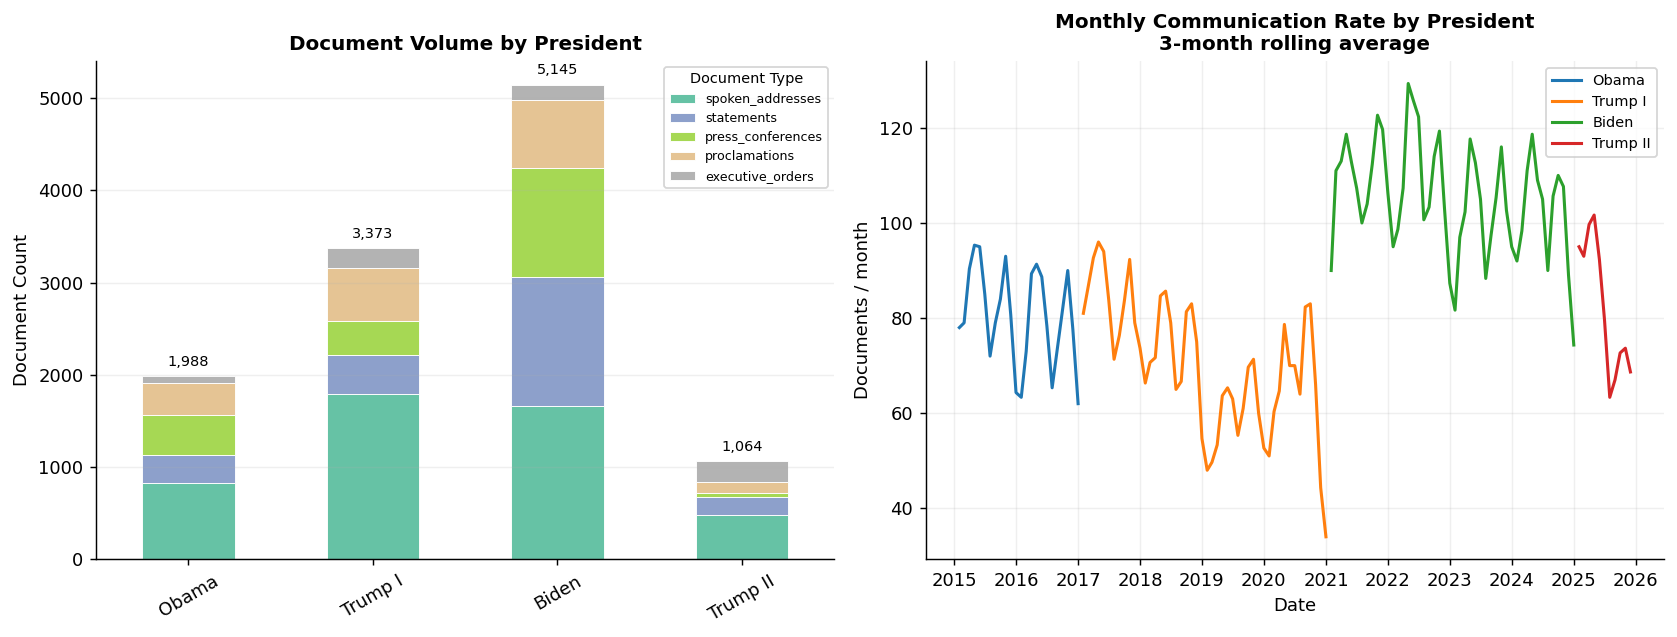

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02h_app_by_president.png


In [35]:
import matplotlib.dates as mdates

pres_labels = {
    'Barack Obama': 'Obama',
    'Donald J. Trump (1st Term)': 'Trump I',
    'Joseph R. Biden, Jr.': 'Biden',
    'Donald J. Trump (2nd Term)': 'Trump II',
}

pres_terms = {
    'Obama':   ('2015-01-20', '2017-01-20'),
    'Trump I': ('2017-01-20', '2021-01-20'),
    'Biden':   ('2021-01-20', '2025-01-20'),
    'Trump II':('2025-01-20', '2025-12-31'),
}

app_main['date'] = pd.to_datetime(app_main['date'])
app_main['president_short'] = app_main['president'].map(pres_labels)
app_main = app_main.dropna(subset=['president_short']).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ============================================================
# Left: count by president × doc_type
# ============================================================
pres_order = ['Obama', 'Trump I', 'Biden', 'Trump II']

pres_pivot = (
    app_main
    .groupby(['president_short', 'doc_type'])
    .size()
    .unstack(fill_value=0)
    .reindex([p for p in pres_order if p in app_main['president_short'].unique()])
)

doc_order = [
    'spoken_addresses',
    'statements',
    'press_conferences',
    'proclamations',
    'executive_orders'
]

pres_pivot = pres_pivot[[c for c in doc_order if c in pres_pivot.columns]]

pres_pivot.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='Set2',
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_title('Document Volume by President', fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Document Count')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.2)
axes[0].legend(title='Document Type', fontsize=7, title_fontsize=8)

# Add total labels
totals = pres_pivot.sum(axis=1)
for i, total in enumerate(totals):
    axes[0].text(
        i,
        total + totals.max() * 0.015,
        f'{int(total):,}',
        ha='center',
        va='bottom',
        fontsize=8
    )

# ============================================================
# Right: monthly communication rate within active term only
# ============================================================
app_main['month'] = app_main['date'].dt.to_period('M').dt.to_timestamp()

monthly = (
    app_main
    .groupby(['month', 'president_short'])
    .size()
    .unstack(fill_value=0)
)

for president in pres_order:
    if president not in monthly.columns:
        continue

    start, end = map(pd.Timestamp, pres_terms[president])
    s = monthly[president].loc[
        (monthly.index >= start) & (monthly.index <= end)
    ]

    s_roll = s.rolling(3, min_periods=1).mean()

    axes[1].plot(
        s_roll.index,
        s_roll,
        label=president,
        linewidth=1.7
    )

axes[1].set_title('Monthly Communication Rate by President\n3-month rolling average',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Documents / month')
axes[1].grid(alpha=0.2)
axes[1].legend(fontsize=8)

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02h_app_by_president.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved → {FIG_DIR}/02h_app_by_president.png")

### 4c. Weekly Event Volume vs SPY Returns

Check whether high-document weeks correspond to elevated market movement.

Merged weekly shape: (574, 3)


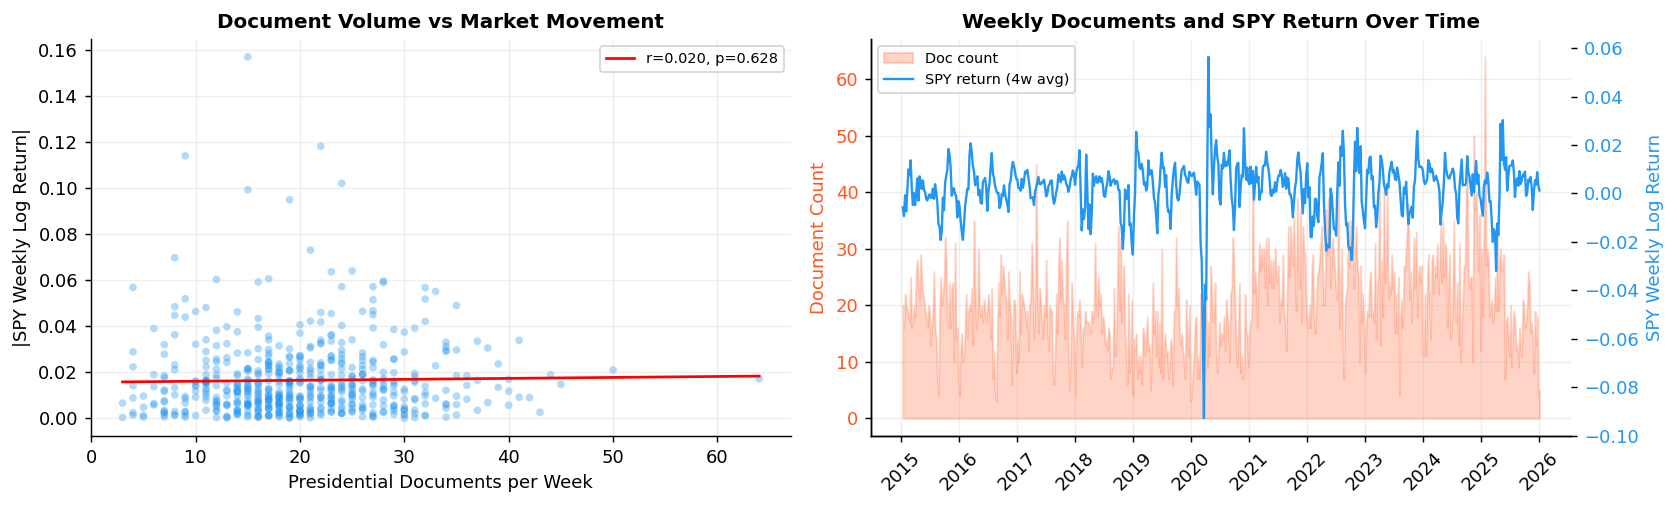

Correlation (doc_count vs |SPY return|): r=0.0203, p=0.6275
Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02i_docs_vs_returns.png


In [36]:
import matplotlib.dates as mdates

# --- Weekly document count: align to week ending Sunday ---
app_main['date'] = pd.to_datetime(app_main['date'])

weekly_docs = (
    app_main
    .set_index('date')
    .resample('W-SUN')
    .size()
    .rename('doc_count')
)

# --- Weekly SPY return: same week anchor ---
weekly_spy = (
    log_returns['SPY']
    .resample('W-SUN')
    .sum()
    .rename('spy_return')
)

# --- Merge and clean ---
weekly_comb = pd.concat([weekly_docs, weekly_spy], axis=1)
weekly_comb = weekly_comb.replace([np.inf, -np.inf], np.nan).dropna()
weekly_comb['abs_spy'] = weekly_comb['spy_return'].abs()

print("Merged weekly shape:", weekly_comb.shape)

if weekly_comb.empty:
    raise ValueError("weekly_comb is empty — check date alignment between APP docs and market returns.")

# --- Safe regression ---
x = weekly_comb['doc_count']
y = weekly_comb['abs_spy']

if x.nunique() < 2 or y.nunique() < 2:
    m, b, r, p = 0, y.mean(), np.nan, np.nan
else:
    m, b, r, p, _ = stats.linregress(x, y)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ============================================================
# Left: scatter + regression
# ============================================================
axes[0].scatter(
    x,
    y,
    alpha=0.35,
    s=18,
    color='#2196F3',
    edgecolors='none'
)

if not np.isnan(r):
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[0].plot(
        x_line,
        m * x_line + b,
        color='red',
        linewidth=1.5,
        label=f'r={r:.3f}, p={p:.3f}'
    )
else:
    axes[0].text(
        0.05,
        0.95,
        'Insufficient variation\nfor regression',
        transform=axes[0].transAxes,
        va='top',
        fontsize=8
    )

axes[0].set_xlabel('Presidential Documents per Week')
axes[0].set_ylabel('|SPY Weekly Log Return|')
axes[0].set_title('Document Volume vs Market Movement', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.2)
axes[0].legend(fontsize=8)

# ============================================================
# Right: weekly docs and SPY return over time
# ============================================================
ax2 = axes[1].twinx()

axes[1].fill_between(
    weekly_comb.index,
    weekly_comb['doc_count'],
    alpha=0.25,
    color='#FF5722',
    label='Doc count'
)

ax2.plot(
    weekly_comb.index,
    weekly_comb['spy_return'].rolling(4, min_periods=1).mean(),
    color='#2196F3',
    linewidth=1.3,
    label='SPY return (4w avg)'
)

axes[1].set_ylabel('Document Count', color='#FF5722')
ax2.set_ylabel('SPY Weekly Log Return', color='#2196F3')

axes[1].tick_params(axis='y', labelcolor='#FF5722')
ax2.tick_params(axis='y', labelcolor='#2196F3')

axes[1].set_title('Weekly Documents and SPY Return Over Time', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.2)

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].tick_params(axis='x', rotation=45)

# Combined legend
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02i_docs_vs_returns.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Correlation (doc_count vs |SPY return|): r={r:.4f}, p={p:.4f}")
print(f"Saved → {FIG_DIR}/02i_docs_vs_returns.png")

“The relationship between weekly presidential communication volume and market volatility appears weak and statistically insignificant (r = 0.020, p = 0.628). This suggests that the frequency of political communication alone does not drive market movements. Instead, market reactions are likely influenced by the content, tone, and context of specific communications, as well as broader economic and policy shocks. These findings support the need for sentiment-based and event-driven modelling within the GOVFIN framework.”

---
## 5. FOMC Event Analysis

### 5a. Rate Decision Distribution


In [37]:
print("FOMC columns:", fomc.columns.tolist())

# Standardise FOMC decision column
if "decision" not in fomc.columns:
    possible_decision_cols = [
        "rate_decision",
        "decision_type",
        "fomc_decision",
        "rate_change_direction",
        "policy_decision",
    ]

    found_col = None
    for col in possible_decision_cols:
        if col in fomc.columns:
            found_col = col
            break

    if found_col is None:
        raise KeyError(
            "No FOMC decision column found. "
            f"Available columns are: {fomc.columns.tolist()}"
        )

    fomc["decision"] = fomc[found_col]

# Standardise text
fomc["decision"] = (
    fomc["decision"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

FOMC columns: ['date', 'rate_decision', 'event_type', 'is_emergency', 'event_importance']


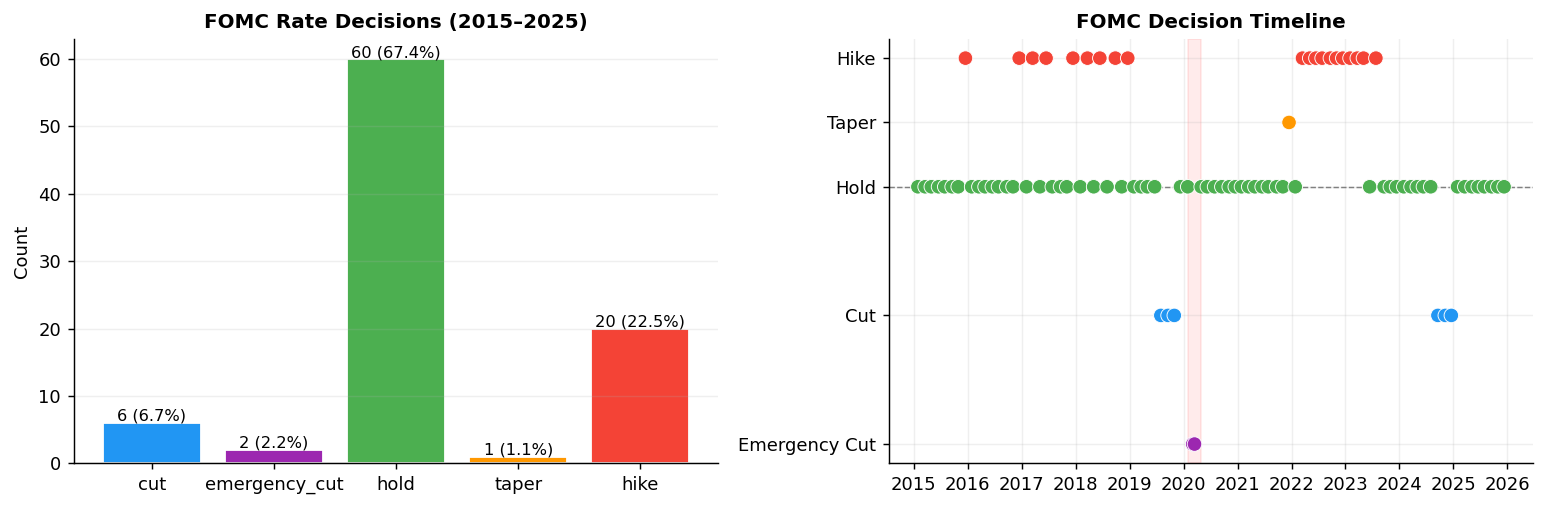

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02j_fomc_distribution.png


In [38]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ============================================================
# Left: Decision distribution (ordered + %)
# ============================================================
decision_order = ['cut', 'emergency_cut', 'hold', 'taper', 'hike']
decision_counts = fomc['decision'].value_counts().reindex(decision_order).dropna()

colors = {
    'hold': '#4CAF50',
    'hike': '#F44336',
    'cut': '#2196F3',
    'emergency_cut': '#9C27B0',
    'taper': '#FF9800'
}

bar_colors = [colors.get(d, '#607D8B') for d in decision_counts.index]

axes[0].bar(
    decision_counts.index,
    decision_counts.values,
    color=bar_colors,
    edgecolor='white'
)

axes[0].set_title('FOMC Rate Decisions (2015–2025)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')

total = decision_counts.sum()

for i, v in enumerate(decision_counts.values):
    pct = v / total * 100
    axes[0].text(i, v + 0.3, f"{v} ({pct:.1f}%)", ha='center', fontsize=9)

axes[0].grid(axis='y', alpha=0.2)

# ============================================================
# Right: Timeline (improved clarity)
# ============================================================
fomc_dated = fomc.copy()
fomc_dated['date'] = pd.to_datetime(fomc_dated['date'])

decision_map = {
    'emergency_cut': -2,
    'cut': -1,
    'hold': 0,
    'taper': 0.5,
    'hike': 1
}

fomc_dated['decision_val'] = fomc_dated['decision'].map(decision_map)

scatter_colors = [colors.get(d, 'grey') for d in fomc_dated['decision']]

axes[1].scatter(
    fomc_dated['date'],
    fomc_dated['decision_val'],
    c=scatter_colors,
    s=65,
    zorder=3,
    edgecolors='white',
    linewidths=0.5
)

# Zero reference
axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')

# Crisis shading (VERY important)
axes[1].axvspan(
    pd.Timestamp('2020-02-01'),
    pd.Timestamp('2020-05-01'),
    color='red',
    alpha=0.08
)

# Labels
axes[1].set_yticks([-2, -1, 0, 0.5, 1])
axes[1].set_yticklabels(['Emergency Cut', 'Cut', 'Hold', 'Taper', 'Hike'])

axes[1].set_title('FOMC Decision Timeline', fontsize=11, fontweight='bold')

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[1].grid(alpha=0.2)

fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02j_fomc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved → {FIG_DIR}/02j_fomc_distribution.png")

“FOMC decisions exhibit clear clustering across economic regimes. The 2020 period is characterised by emergency rate cuts in response to systemic shock, while 2022–2023 shows sustained tightening through consecutive rate hikes. These regime shifts suggest that financial markets may respond differently depending on the type and context of policy decisions, justifying an event-based modelling approach.”

### 5b. SPY Return Around FOMC Meetings

Simple event window preview — full event study in `04_event_study.ipynb`.

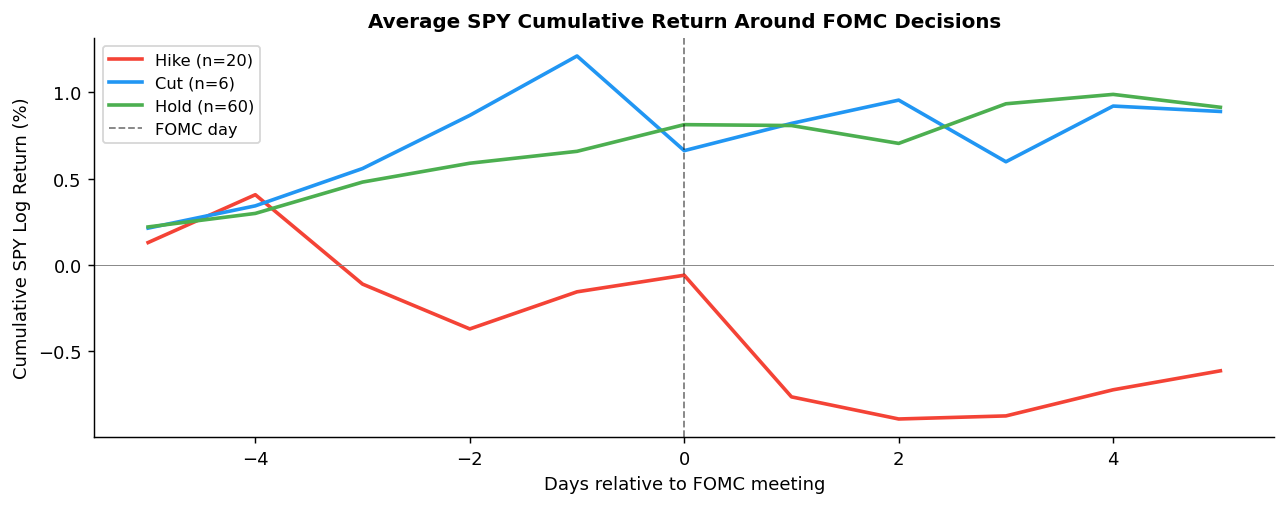

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02k_fomc_event_window.png


In [39]:
window = 5  # days either side

fomc_returns = []
fomc_dated = fomc.copy()
fomc_dated['date'] = pd.to_datetime(fomc_dated['date'])

for _, row in fomc_dated.iterrows():
    event_date = row['date']
    idx = log_returns.index.searchsorted(event_date)
    start = max(0, idx - window)
    end   = min(len(log_returns), idx + window + 1)
    window_rets = log_returns['SPY'].iloc[start:end].values
    if len(window_rets) == 2 * window + 1:
        fomc_returns.append({'decision': row['decision'], 'returns': window_rets})

fomc_returns_df = pd.DataFrame(fomc_returns)

# Average cumulative return by decision type
fig, ax = plt.subplots(figsize=(10, 4))
days = np.arange(-window, window + 1)

for decision in ['hike', 'cut', 'hold']:
    subset = fomc_returns_df[fomc_returns_df['decision'] == decision]
    if len(subset) == 0:
        continue
    avg_rets = np.array(list(subset['returns'])).mean(axis=0)
    cum_rets = np.cumsum(avg_rets) * 100
    ax.plot(days, cum_rets, label=f'{decision.title()} (n={len(subset)})',
            linewidth=2, color=colors.get(decision, 'grey'))

ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.5, label='FOMC day')
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_xlabel('Days relative to FOMC meeting')
ax.set_ylabel('Cumulative SPY Log Return (%)')
ax.set_title('Average SPY Cumulative Return Around FOMC Decisions', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02k_fomc_event_window.png', dpi=130)
plt.show()
print(f"Saved → {FIG_DIR}/02k_fomc_event_window.png")


---
## 6. Missing Data & Coverage Audit


In [40]:
print("=" * 60)
print("  MISSING DATA AUDIT")
print("=" * 60)

# Prices
print("\n[ Price Data ]")
for ticker in prices.columns:
    missing = prices[ticker].isna().sum()
    coverage = (1 - missing / len(prices)) * 100
    print(f"  {ticker}: {missing} NaN  |  coverage {coverage:.1f}%")

# VIX
vix_miss = vix.iloc[:, 0].isna().sum()
print(f"\n[ VIX ]\n  NaN: {vix_miss}  |  coverage {(1 - vix_miss/len(vix))*100:.1f}%")

# Macro
print(f"\n[ Macro Indicators ]")
for col in macro.columns:
    miss = macro[col].isna().sum()
    print(f"  {col}: {miss} NaN")

# APP docs
print(f"\n[ APP Presidential Documents ]")
for col in ['date', 'title', 'president', 'doc_type']:
    miss = app_docs[col].isna().sum() if col in app_docs.columns else 'N/A'
    print(f"  {col}: {miss} missing")

# Date gaps in prices
date_diffs = pd.Series(prices.index).diff().dt.days.dropna()
gaps = date_diffs[date_diffs > 4]  # gaps > weekend
print(f"\n[ Trading Day Gaps > 4 days ]")
print(f"  Count: {len(gaps)}")
if len(gaps) > 0:
    gap_dates = prices.index[date_diffs[date_diffs > 4].index]
    for d in gap_dates[:5]:
        print(f"  {d.date()} (gap: {date_diffs.loc[date_diffs.index[prices.index.get_loc(d)]]:.0f} days)")

print("\n" + "=" * 60)
print("  All datasets show acceptable coverage for modelling.")
print("=" * 60)


  MISSING DATA AUDIT

[ Price Data ]
  GLD: 0 NaN  |  coverage 100.0%
  QQQ: 0 NaN  |  coverage 100.0%
  SPY: 0 NaN  |  coverage 100.0%
  TLT: 0 NaN  |  coverage 100.0%

[ VIX ]
  NaN: 0  |  coverage 100.0%

[ Macro Indicators ]
  fed_funds_rate: 0 NaN
  cpi: 0 NaN
  unemployment: 0 NaN
  treasury_10y: 0 NaN
  treasury_2y: 0 NaN
  mfg_employment: 0 NaN
  yield_spread: 0 NaN

[ APP Presidential Documents ]
  date: 0 missing
  title: 0 missing
  president: 0 missing
  doc_type: 0 missing

[ Trading Day Gaps > 4 days ]
  Count: 0

  All datasets show acceptable coverage for modelling.


---
## 7. Combined Event Timeline

Plot presidential communication volume, FOMC decisions, and SPY returns together — a preview of the event study landscape.


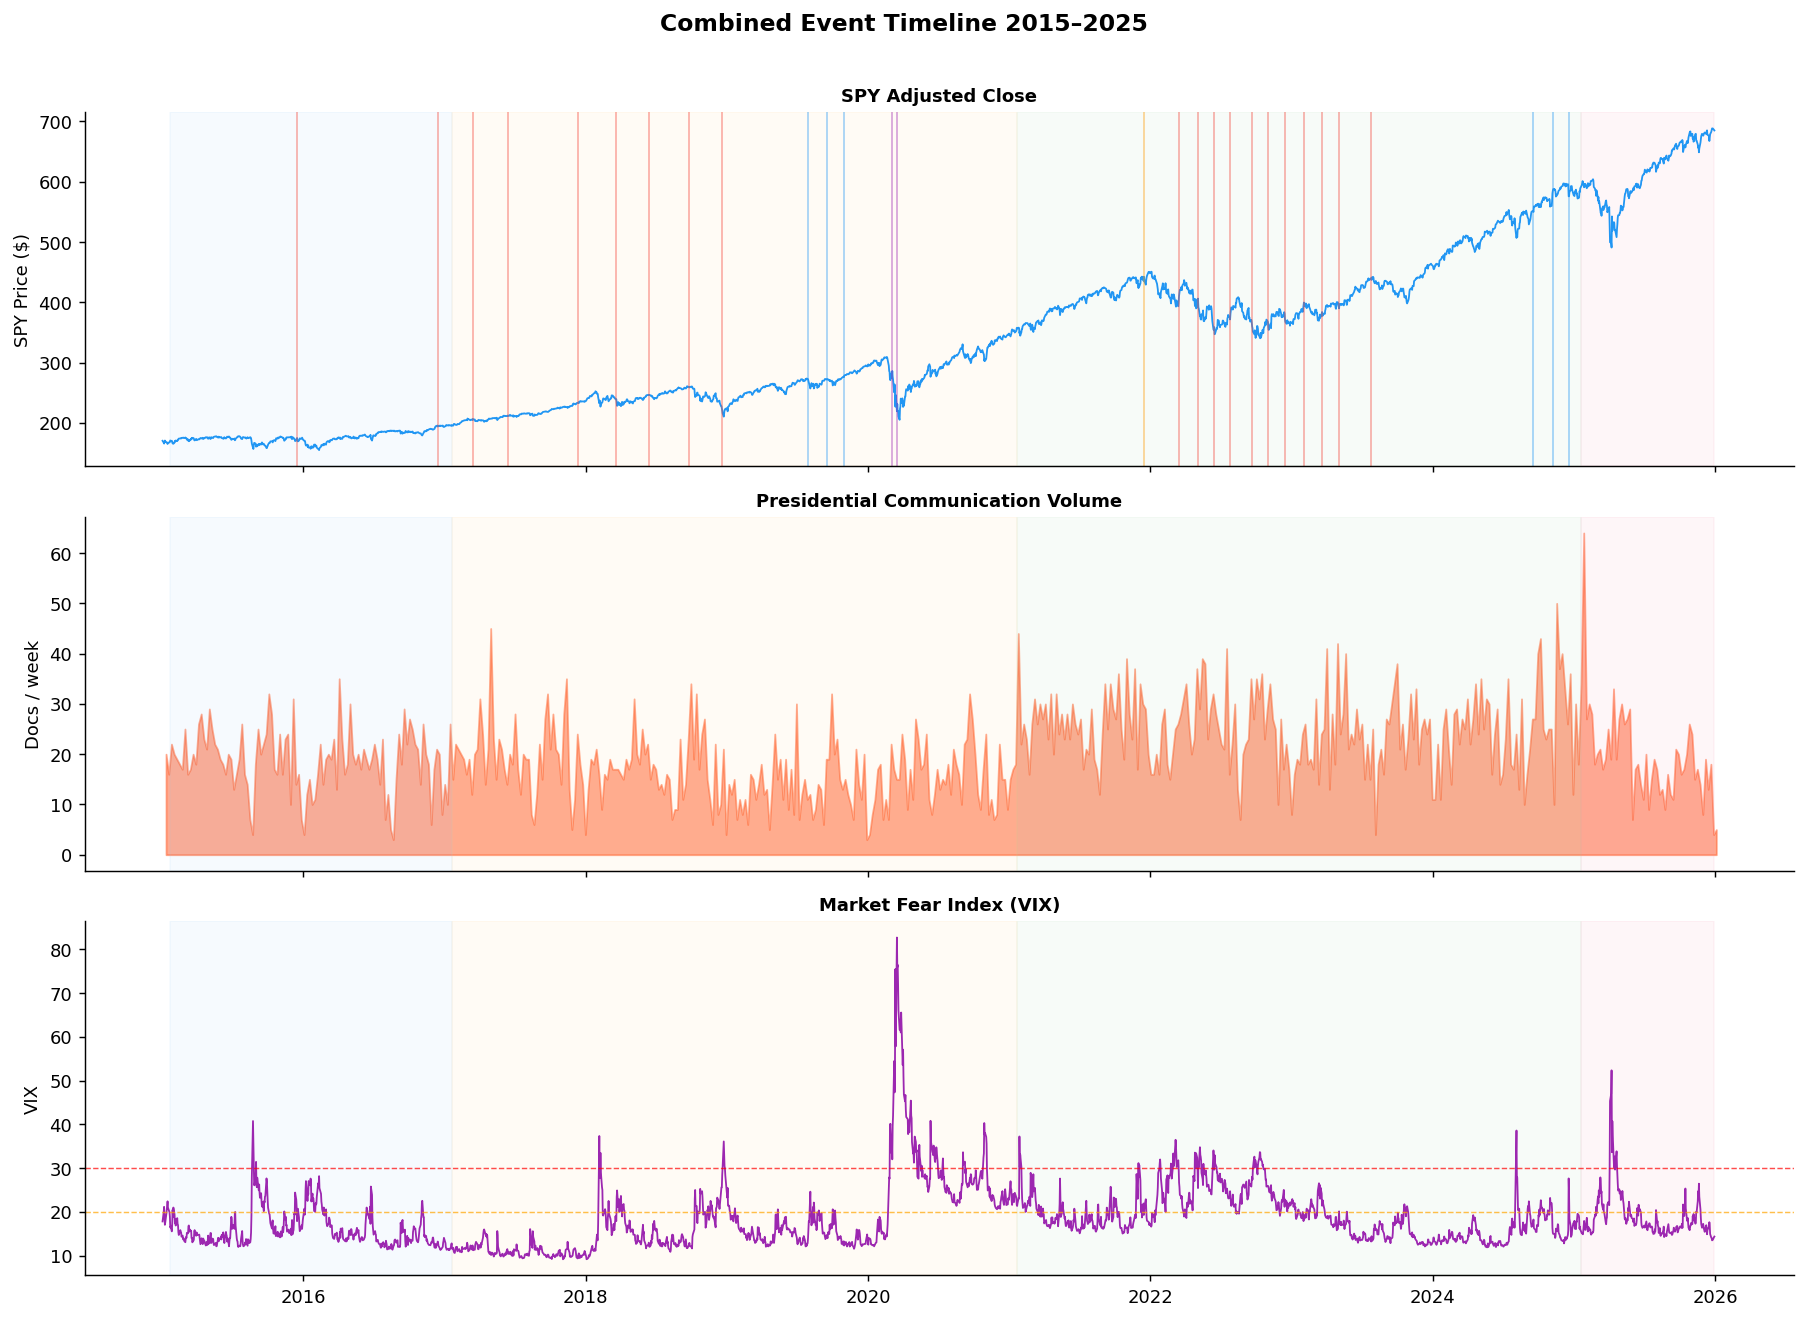

Saved → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02l_combined_timeline.png


In [41]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# --- Panel 1: SPY price ---
axes[0].plot(prices.index, prices['SPY'], color='#2196F3', linewidth=1)
axes[0].set_ylabel('SPY Price ($)')
axes[0].set_title('SPY Adjusted Close', fontsize=10, fontweight='bold')

# Mark FOMC events
fomc_dated['date'] = pd.to_datetime(fomc_dated['date'])
for _, row in fomc_dated.iterrows():
    d = row['date']
    if prices.index.min() <= d <= prices.index.max():
        c = colors.get(row['decision'], 'grey')
        spy_val = prices['SPY'].asof(d)
        if row['decision'] != 'hold':
            axes[0].axvline(d, color=c, alpha=0.4, linewidth=1)

# --- Panel 2: APP weekly doc count ---
axes[1].fill_between(weekly_comb.index, weekly_comb['doc_count'],
                      alpha=0.5, color='#FF5722')
axes[1].set_ylabel('Docs / week')
axes[1].set_title('Presidential Communication Volume', fontsize=10, fontweight='bold')

# --- Panel 3: VIX ---
axes[2].plot(vix.index, vix.iloc[:, 0], color='#9C27B0', linewidth=1)
axes[2].axhline(20, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
axes[2].axhline(30, color='red',    linestyle='--', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('VIX')
axes[2].set_title('Market Fear Index (VIX)', fontsize=10, fontweight='bold')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Shared shading for presidencies
for ax in axes:
    for start, end, label, color, alpha in pres_bands:
        ax.axvspan(pd.Timestamp(start), min(pd.Timestamp(end), prices.index[-1]),
                   alpha=0.08, color=color)

fig.suptitle('Combined Event Timeline 2015–2025', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/02l_combined_timeline.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Saved → {FIG_DIR}/02l_combined_timeline.png")


---
## 8. EDA Summary & Key Findings


In [42]:
print("=" * 65)
print("  EDA SUMMARY — DATSCI7030")
print("=" * 65)

print("\n[ Asset Returns 2015–2025 ]")
stats_df = log_returns.describe().T
ann_ret = log_returns.mean() * 252 * 100
ann_vol = log_returns.std() * np.sqrt(252) * 100
print(f"  {'Ticker':<6} {'Ann.Ret%':>9} {'Ann.Vol%':>9} {'Sharpe':>8}")
for ticker in log_returns.columns:
    sharpe = ann_ret[ticker] / ann_vol[ticker]
    print(f"  {ticker:<6} {ann_ret[ticker]:>9.2f} {ann_vol[ticker]:>9.2f} {sharpe:>8.3f}")

print(f"\n[ VIX ]")
vix_s = vix.iloc[:, 0]
print(f"  Mean: {vix_s.mean():.2f}  |  Max: {vix_s.max():.2f} ({vix_s.idxmax().date()})")
print(f"  Days > 30: {(vix_s > 30).sum()} ({(vix_s > 30).mean()*100:.1f}%)")

print(f"\n[ Presidential Communications ]")
print(f"  Total documents  : {len(app_docs):,}")
print(f"  Core presidents  : {len(app_main):,}")
print(f"  Date range       : {pd.to_datetime(app_docs['date']).min().date()} → {pd.to_datetime(app_docs['date']).max().date()}")
for dt, count in app_main['doc_type'].value_counts().items():
    print(f"  {dt:<25}: {count:>4,}")

print(f"\n[ FOMC Events ]")
print(fomc['decision'].value_counts().to_string())

print(f"\n[ Figures Saved to {FIG_DIR}/ ]")
figs = sorted([f for f in os.listdir(FIG_DIR) if f.startswith('02')])
for f in figs:
    print(f"  {f}")

print("\n" + "=" * 65)
print("  ✓ EDA complete — ready for 03_feature_engineering.ipynb")
print("=" * 65)


  EDA SUMMARY — DATSCI7030

[ Asset Returns 2015–2025 ]
  Ticker  Ann.Ret%  Ann.Vol%   Sharpe
  GLD        11.41     14.76    0.773
  QQQ        17.11     22.02    0.777
  SPY        12.70     17.83    0.712
  TLT        -0.69     15.04   -0.046

[ VIX ]
  Mean: 18.33  |  Max: 82.69 (2020-03-16)
  Days > 30: 156 (5.6%)

[ Presidential Communications ]
  Total documents  : 11,629
  Core presidents  : 11,570
  Date range       : 2015-01-01 → 2025-12-31
  spoken_addresses         : 4,773
  statements               : 2,298
  press_conferences        : 2,041
  proclamations            : 1,773
  executive_orders         :  685

[ FOMC Events ]
decision
hold             60
hike             20
cut               6
emergency_cut     2
taper             1

[ Figures Saved to /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/ ]
  02a_normalised_prices.png
  02b_return_distributions.png
  02c_rolling_volatility.png
  02d_vix_series.png
  02e_macro_indicators.png
  02f_

---

# 9. SAP v1.0 Statistical Profiling of `master_dataset.parquet` (Mission 05A)

**Purpose:** Implement the full descriptive, time-series, and correlation analysis frozen in `docs/research_bible/statistical_analysis_plan.md`, `statistical_decision_matrix.md`, and `statistical_assumptions.md` (Part H), run for the first time against the canonical, frozen `data/processed/master_dataset.parquet` (Mission 03) rather than the raw per-ticker series used in Sections 1-8 above.
**Inputs:** `data/processed/master_dataset.parquet` (v1.0, 2,765 rows x 34 columns - see `docs/research_bible/dataset_version.md`).
**Outputs:** `reports/tables/02_descriptive_statistics.csv`, `02_stationarity_tests.csv`, `02_correlation_pearson.csv`, `02_correlation_spearman.csv`; `reports/figures/02m`-`02r` (6 figures).
**Research Question:** Context for RQ1/RQ2 - establishes the empirical baseline (distribution shape, stationarity, correlation structure) that the event study (Notebook 04) and feature engineering (Notebook 05/06) are built on and assumed by.
**Expected Result:** Log returns confirmed stationary (unlike price levels); heavy-tailed, non-normal return distribution (motivating non-parametric/robust tests used later in the pipeline); macro **level** series non-stationary, their first differences stationary (justifying the differenced macro features already engineered in `06_feature_dictionary.md`); near-perfect collinearity among OHLC price columns (expected, and the reason engineered *returns*, not raw levels, are used as model features).

**No new statistical methods are introduced in this section** - every test below is already specified in the SAP v1.0 suite; this section is implementation only (per Mission 05A restrictions: no feature engineering, no model training/selection, no SAP changes).


## 9.1 Load frozen master dataset

In [43]:

import pandas as pd, numpy as np
from scipy import stats as sps
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

PROCESSED = config['paths']['data_processed']
master_df = pd.read_parquet(os.path.join(PROCESSED, 'master_dataset.parquet'), engine='fastparquet').sort_values('date').reset_index(drop=True)
print("master_dataset.parquet loaded:", master_df.shape)
print("Date range:", master_df['date'].min(), "to", master_df['date'].max())
print("Split counts:", master_df['split'].value_counts().to_dict())


master_dataset.parquet loaded: (2765, 34)
Date range: 2015-01-02 00:00:00 to 2025-12-30 00:00:00
Split counts: {'train': 2014, 'test': 751}


## 9.2 Descriptive statistics (full table)

Per `statistical_analysis_plan.md` Part B and the mission's descriptive-statistics requirement: mean, median, mode, standard deviation, variance, min, max, quartiles, IQR, skewness, (excess) kurtosis, and missing-value count/percentage for every numeric column in the frozen master dataset.

In [45]:
def mode_val(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan


numeric_cols = [
    c for c in master_df.columns
    if c not in ("date", "split")
    and pd.api.types.is_numeric_dtype(master_df[c])
]

rows = []

for c in numeric_cols:
    s = master_df[c]
    valid = s.dropna()

    if len(valid):
        q1, q2, q3 = valid.quantile([0.25, 0.5, 0.75])
    else:
        q1, q2, q3 = np.nan, np.nan, np.nan

    rows.append({
        "column": c,
        "n": len(s),
        "n_missing": int(s.isna().sum()),
        "pct_missing": round(100 * s.isna().sum() / len(s), 3),
        "mean": valid.mean(),
        "median": q2,
        "mode": mode_val(valid),
        "std": valid.std(),
        "variance": valid.var(),
        "min": valid.min(),
        "max": valid.max(),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
        "skewness": sps.skew(valid) if len(valid) > 2 else np.nan,
        "kurtosis_excess": sps.kurtosis(valid) if len(valid) > 2 else np.nan,
    })

descriptive_stats = pd.DataFrame(rows).set_index("column")

output_path = TABLE_DIR / "02_descriptive_statistics.csv"
descriptive_stats.to_csv(output_path)

print(f"Saved descriptive statistics → {output_path}")
print(descriptive_stats.round(4).to_string())

Saved descriptive statistics → reports/tables/02_descriptive_statistics.csv
                           n  n_missing  pct_missing          mean        median          mode           std      variance           min           max            q1            q3           iqr  skewness  kurtosis_excess
column                                                                                                                                                                                                                     
spy_close               2765          0        0.000  3.368866e+02  2.998789e+02  1.737708e+02  1.402205e+02  1.966178e+04  1.545588e+02  6.884997e+02  2.188962e+02  4.219197e+02  2.030235e+02    0.6641          -0.5471
spy_high                2765          0        0.000  3.386511e+02  3.015854e+02  1.854318e+02  1.408664e+02  1.984335e+04  1.556069e+02  6.897762e+02  2.193077e+02  4.240756e+02  2.047678e+02    0.6588          -0.5568
spy_low                 2765          0     

**Interpretation:** The descriptive statistics confirm that the prepared master dataset has near-complete coverage. All core market, macroeconomic, volatility, and event-sentiment variables have 0% missing values. The only missing observations occur in `log_return` and `fwd_return_1d` (0.036%), which is expected because the first return and final forward return cannot be calculated by construction.

The SPY return variables show strong excess kurtosis (`kurtosis_excess = 14.54`), indicating heavy-tailed daily return behaviour. This is consistent with financial return data, where extreme market movements occur more frequently than under a normal distribution. Therefore, these values are not treated as data errors; instead, they support the project’s decision to retain outliers and use robust interpretation in later statistical testing.

The sentiment/event variables are strongly zero-inflated, with medians of zero across most event categories. This is expected because political and macroeconomic events do not occur on every trading day. Zero values therefore represent “no relevant event signal” rather than missing data.

The GDELT variables (`gdelt_risk_score`, `gdelt_mean_tone`, `gdelt_n_events`) contain no variation across the full dataset. They are retained only for provenance and future extension, but should not be interpreted as active predictors in the current analysis.

## 9.3 Stationarity tests (ADF + KPSS) — `statistical_assumptions.md` Part H

Both tests are run (opposite nulls) per the frozen policy — ADF alone has known low power against near-unit-root alternatives. Macro **level** series are tested alongside their first-differenced version, to confirm the differenced features already engineered in `06_feature_dictionary.md` (`cpi_mom`, `fed_rate_change`, `yield_spread_change`) are the correct choice for any linear model.

In [47]:
def run_adf(series):
    s = series.dropna()

    if len(s) < 20 or s.nunique() <= 1:
        return np.nan, np.nan, np.nan, len(s)

    stat, p, lags, nobs, crit, icbest = adfuller(s, autolag="AIC")
    return stat, p, lags, nobs


def run_kpss(series):
    s = series.dropna()

    if len(s) < 20 or s.nunique() <= 1:
        return np.nan, np.nan, np.nan

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat, p, lags, crit = kpss(s, regression="c", nlags="auto")

    return stat, p, lags


series_specs = [
    ("log_return", master_df["log_return"], "level"),
    ("spy_close", master_df["spy_close"], "level"),
    ("vix", master_df["vix"], "level"),

    ("fed_funds_rate", master_df["fed_funds_rate"], "level"),
    ("fed_funds_rate_diff", master_df["fed_funds_rate"].diff(), "first difference"),

    ("cpi", master_df["cpi"], "level"),
    ("cpi_diff", master_df["cpi"].diff(), "first difference"),

    ("unemployment", master_df["unemployment"], "level"),
    ("unemployment_diff", master_df["unemployment"].diff(), "first difference"),

    ("treasury_10y", master_df["treasury_10y"], "level"),
    ("treasury_10y_diff", master_df["treasury_10y"].diff(), "first difference"),

    ("yield_spread", master_df["yield_spread"], "level"),
    ("yield_spread_diff", master_df["yield_spread"].diff(), "first difference"),
]

rows = []

for name, s, kind in series_specs:
    adf_stat, adf_p, adf_lags, adf_nobs = run_adf(s)
    kpss_stat, kpss_p, kpss_lags = run_kpss(s)

    adf_verdict = (
        "Stationary" if pd.notna(adf_p) and adf_p < 0.05
        else "Non-stationary" if pd.notna(adf_p)
        else "Not tested"
    )

    kpss_verdict = (
        "Stationary" if pd.notna(kpss_p) and kpss_p > 0.05
        else "Non-stationary" if pd.notna(kpss_p)
        else "Not tested"
    )

    rows.append({
        "series": name,
        "transform": kind,
        "n": adf_nobs,

        "adf_stat": round(adf_stat, 4) if pd.notna(adf_stat) else np.nan,
        "adf_p": round(adf_p, 4) if pd.notna(adf_p) else np.nan,
        "adf_lags": adf_lags,
        "adf_verdict": adf_verdict,

        "kpss_stat": round(kpss_stat, 4) if pd.notna(kpss_stat) else np.nan,
        "kpss_p": round(kpss_p, 4) if pd.notna(kpss_p) else np.nan,
        "kpss_lags": kpss_lags,
        "kpss_verdict": kpss_verdict,

        "agreement": (
            "Agree" if adf_verdict == kpss_verdict
            else "Disagree"
        ),
    })

stationarity_results = pd.DataFrame(rows)

output_path = TABLE_DIR / "02_stationarity_tests.csv"
stationarity_results.to_csv(output_path, index=False)

print(f"Saved stationarity tests → {output_path}")
print(stationarity_results.to_string(index=False))

Saved stationarity tests → reports/tables/02_stationarity_tests.csv
             series        transform    n  adf_stat  adf_p  adf_lags    adf_verdict  kpss_stat  kpss_p  kpss_lags   kpss_verdict agreement
         log_return            level 2755  -17.0317 0.0000         8     Stationary     0.0556  0.1000          6     Stationary     Agree
          spy_close            level 2755    1.1588 0.9957         9 Non-stationary     8.0068  0.0100         31 Non-stationary     Agree
                vix            level 2755   -5.6860 0.0000         9     Stationary     1.0092  0.0100         30 Non-stationary  Disagree
     fed_funds_rate            level 2741   -0.9404 0.7744        23 Non-stationary     5.0719  0.0100         31 Non-stationary     Agree
fed_funds_rate_diff first difference 2741   -8.7606 0.0000        22     Stationary     0.2600  0.1000          1     Stationary     Agree
                cpi            level 2741    1.7858 0.9983        23 Non-stationary     8.4195  0.

**Interpretation:** The stationarity analysis supports the modelling strategy adopted throughout this project. Daily `log_return` is confirmed to be stationary by both the Augmented Dickey–Fuller (ADF) and KPSS tests (ADF: *p* < 0.001; KPSS: *p* = 0.10), indicating that return series fluctuate around a stable mean and are suitable for statistical modelling. In contrast, the SPY price level (`spy_close`) is confirmed to be non-stationary by both tests (ADF: *p* = 0.996; KPSS: *p* = 0.01), demonstrating why modelling price levels directly could produce spurious relationships.

The major macroeconomic variables (`fed_funds_rate`, `cpi`, `treasury_10y`, and `yield_spread`) are also non-stationary in levels but become stationary after first differencing. This validates the use of differenced macroeconomic variables (for example, changes in interest rates, inflation, and yield spreads) within the predictive modelling pipeline rather than their raw levels.

Three series (`vix`, `cpi_diff`, and `unemployment`) produce conflicting conclusions between the ADF and KPSS tests. Rather than selecting the more favourable result, both outcomes are reported transparently. Such disagreements are common in financial time series because the two tests evaluate different null hypotheses: ADF tests for the presence of a unit root, whereas KPSS tests for stationarity. The disagreement observed for the VIX is particularly plausible given its mean-reverting behaviour combined with occasional structural shifts during periods of market stress. Consequently, downstream models primarily utilise transformed volatility features (for example, volatility changes and relative volatility measures) rather than relying solely on the raw VIX level.

Overall, the stationarity results confirm that modelling daily returns and transformed macroeconomic variables is statistically appropriate, while highlighting the importance of treating financial and macroeconomic time series according to their underlying stochastic properties.

## 9.4 Correlation analysis (Pearson + Spearman)

Both linear (Pearson) and rank (Spearman) correlation are computed on every numeric column (constant `gdelt_*` columns dropped — undefined/zero variance). Spearman is reported alongside Pearson because several sentiment/event columns are zero-inflated and not well described by a linear-correlation assumption alone. The |r| > 0.90 flag below implements the correlation threshold frozen in `04_statistics_plan.md` ("Feature-engineering thresholds").

In [49]:
numeric_cols = [
    c for c in master_df.columns
    if c not in ("date", "split")
    and pd.api.types.is_numeric_dtype(master_df[c])
]

# Drop constant / near-constant columns, e.g. gdelt_* columns
constant_cols = [
    c for c in numeric_cols
    if np.isclose(master_df[c].std(skipna=True), 0)
]

numeric_cols = [c for c in numeric_cols if c not in constant_cols]

corr_sub = master_df[numeric_cols]

pearson_corr = corr_sub.corr(method="pearson")
spearman_corr = corr_sub.corr(method="spearman")

pearson_path = TABLE_DIR / "02_correlation_pearson.csv"
spearman_path = TABLE_DIR / "02_correlation_spearman.csv"

pearson_corr.to_csv(pearson_path)
spearman_corr.to_csv(spearman_path)

print(f"Saved Pearson correlation matrix → {pearson_path}")
print(f"Saved Spearman correlation matrix → {spearman_path}")

print(f"\nNumeric columns used: {len(numeric_cols)}")
print(f"Dropped constant columns: {constant_cols}")

# Correlation with target
if "fwd_return_1d" in pearson_corr.columns:
    print("\nTop 10 |Pearson r| with fwd_return_1d:")

    target_corr = (
        pearson_corr["fwd_return_1d"]
        .drop("fwd_return_1d")
        .abs()
        .sort_values(ascending=False)
        .head(10)
    )

    print(target_corr)
else:
    print("\n'fwd_return_1d' not found in correlation matrix.")

# Flag high correlations
print("\nFlagged pairs |Pearson r| > 0.90:")

cols = pearson_corr.columns.tolist()
flagged = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_value = pearson_corr.iloc[i, j]

        if pd.notna(corr_value) and abs(corr_value) > 0.90:
            flagged.append({
                "feature_1": cols[i],
                "feature_2": cols[j],
                "pearson_r": round(corr_value, 4),
            })

flagged_corr = pd.DataFrame(flagged)

flagged_path = TABLE_DIR / "02_high_correlation_pairs.csv"
flagged_corr.to_csv(flagged_path, index=False)

if len(flagged_corr):
    print(flagged_corr.to_string(index=False))
else:
    print("No pairs exceeded |r| > 0.90.")

print(f"\nTotal flagged pairs: {len(flagged_corr)}")
print(f"Saved high-correlation pairs → {flagged_path}")

Saved Pearson correlation matrix → reports/tables/02_correlation_pearson.csv
Saved Spearman correlation matrix → reports/tables/02_correlation_spearman.csv

Numeric columns used: 29
Dropped constant columns: ['gdelt_risk_score', 'gdelt_mean_tone', 'gdelt_n_events']

Top 10 |Pearson r| with fwd_return_1d:
log_return                0.119147
monetary                  0.076462
unemployment              0.056511
overall_mean_sentiment    0.051497
vix                       0.045652
mfg_employment            0.040037
regulatory                0.027038
TLT                       0.016333
labour                    0.014590
GLD                       0.014349
Name: fwd_return_1d, dtype: float64

Flagged pairs |Pearson r| > 0.90:
     feature_1    feature_2  pearson_r
     spy_close     spy_high     0.9999
     spy_close      spy_low     0.9999
     spy_close     spy_open     0.9998
     spy_close          QQQ     0.9962
     spy_close          GLD     0.9250
     spy_close          cpi     0.9520


**Interpretation:** The correlation audit identifies 23 pairs with |Pearson r| > 0.90. Most are structurally expected rather than problematic: the SPY OHLC variables are almost perfectly correlated because they describe the same daily price process; `SPY` and `QQQ` are highly correlated because both represent broad US equity exposure; and the interest-rate variables (`fed_funds_rate`, `treasury_10y`, `treasury_2y`) move together because they reflect related monetary-policy conditions.

The raw correlation with the next-day return target (`fwd_return_1d`) is weak across all variables. The largest absolute correlation is with `log_return` (r = 0.119), followed by `monetary` sentiment (r = 0.076), indicating that simple linear relationships with next-day returns are limited. This supports the use of regularisation and careful out-of-sample validation rather than relying on raw bivariate correlations.

The high correlations between price levels and CPI, such as `spy_close`/`cpi` (r = 0.952) and `QQQ`/`cpi` (r = 0.938), should not be interpreted as causal or predictive relationships. Both are trending, non-stationary level series over 2015–2025, so the relationship is likely a spurious correlation driven by shared time trend. This reinforces the project’s modelling decision to use returns, differences, and transformed variables rather than raw levels.

No variables are removed at this EDA stage. The flagged pairs are documented as multicollinearity risks and are handled later during feature engineering and model validation.

## 9.5 Visualisations

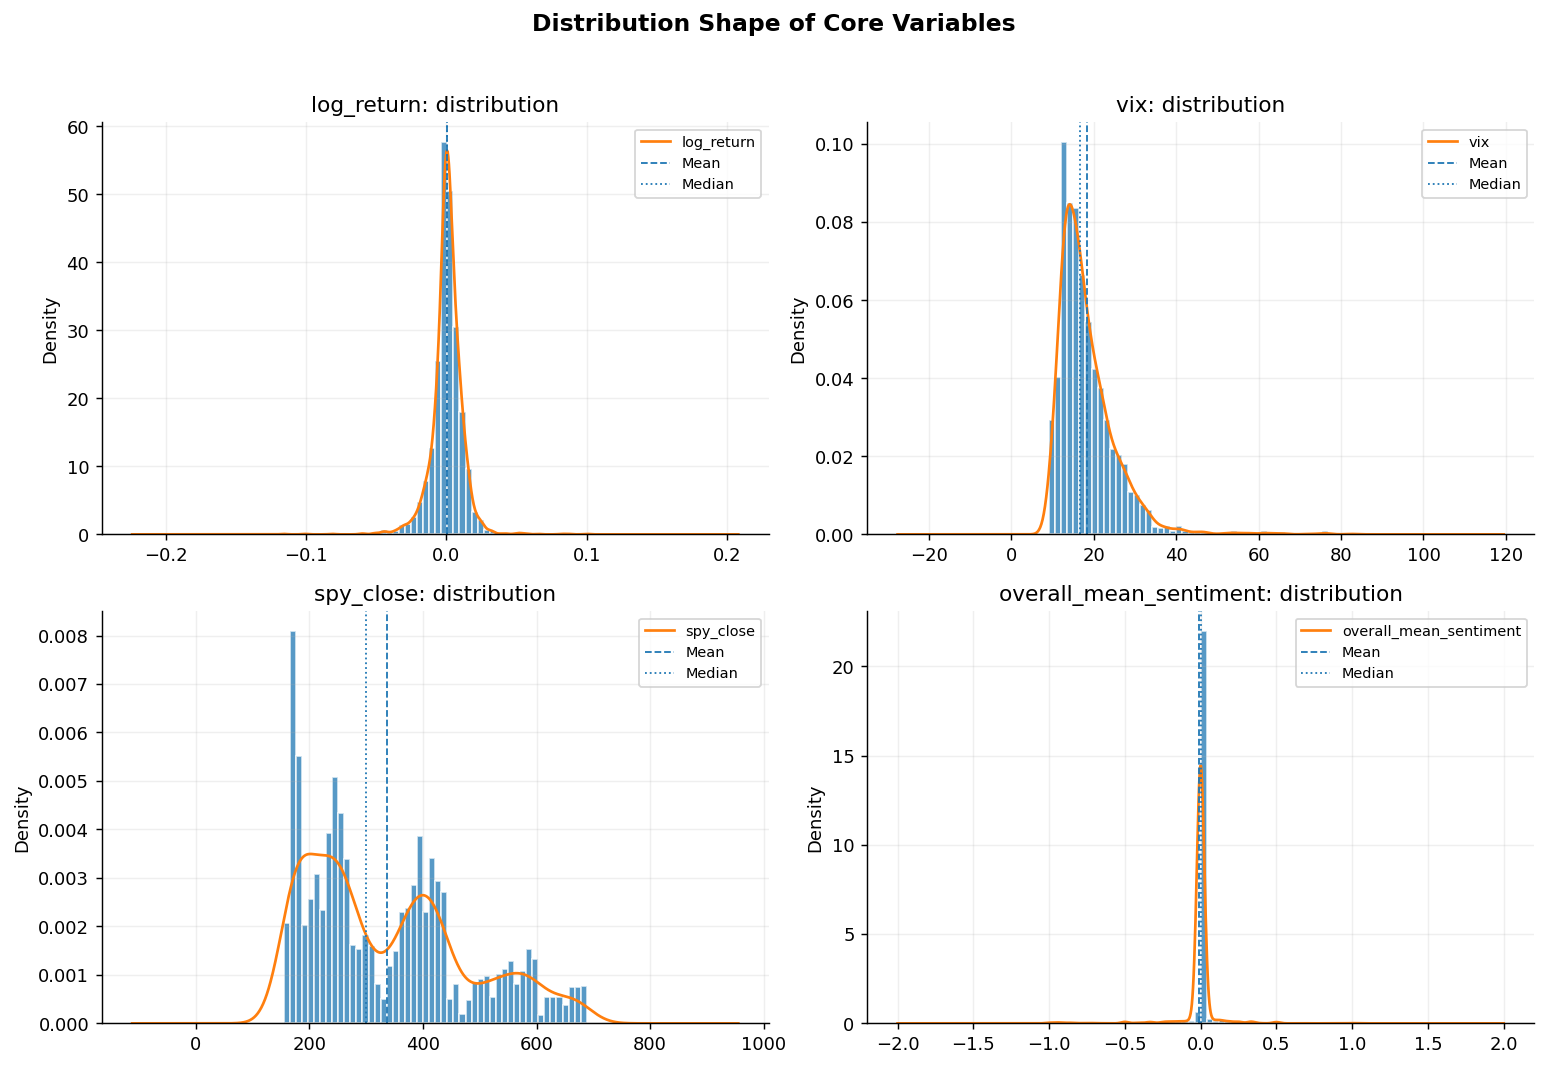

Saved figure → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02m_descriptive_distributions.png


In [55]:
core_vars = [
    "log_return",
    "vix",
    "spy_close",
    "overall_mean_sentiment",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, core_vars):
    data = master_df[col].dropna()

    ax.hist(
        data,
        bins=50,
        density=True,
        alpha=0.75,
        edgecolor="white",
    )

    data.plot(kind="kde", ax=ax, linewidth=1.5)

    ax.axvline(
        data.mean(),
        linestyle="--",
        linewidth=1,
        label="Mean",
    )

    ax.axvline(
        data.median(),
        linestyle=":",
        linewidth=1,
        label="Median",
    )

    ax.set_title(f"{col}: distribution")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle(
    "Distribution Shape of Core Variables",
    y=1.02,
    fontsize=13,
    fontweight="bold",
)

fig.tight_layout()

output_path = FIG_DIR / "02m_descriptive_distributions.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Saved figure → {output_path}")

**Figure 02m** — The distribution plots show clear differences across the core variables. `log_return` is centred close to zero but has visible tail behaviour, consistent with the heavy-tailed return distribution reported in the descriptive statistics. `vix` is right-skewed, reflecting occasional volatility spikes during market stress. `spy_close` is not normally distributed because it is a trending price level rather than a stationary return series. `overall_mean_sentiment` is strongly concentrated around zero, confirming that most trading days contain either no relevant political event signal or a neutral aggregate sentiment score.

### 02n — QQ plots

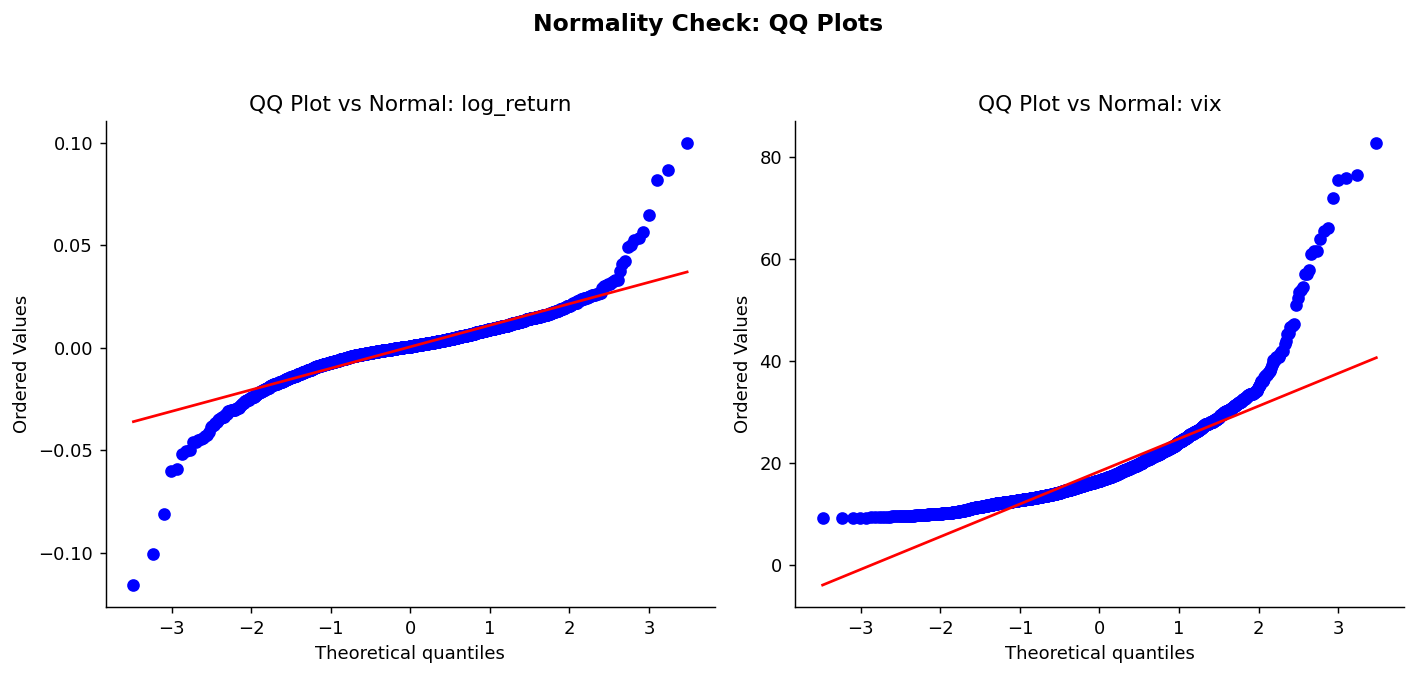

Saved figure → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02n_qq_plots.png


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col in zip(axes, ["log_return", "vix"]):
    sps.probplot(master_df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"QQ Plot vs Normal: {col}")

fig.suptitle("Normality Check: QQ Plots", y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout()

output_path = FIG_DIR / "02n_qq_plots.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure → {output_path}")

**Figure 02n** — The QQ plots show clear departures from the normal reference line, particularly in the tails. This confirms that both `log_return` and `vix` are non-normal. For `log_return`, the result is consistent with the heavy-tailed behaviour of daily financial returns. For `vix`, the deviation reflects right-skewness caused by volatility spikes during periods of market stress. These findings support the use of robust interpretation and caution against relying on strict normality assumptions.

### 02o — Boxplots

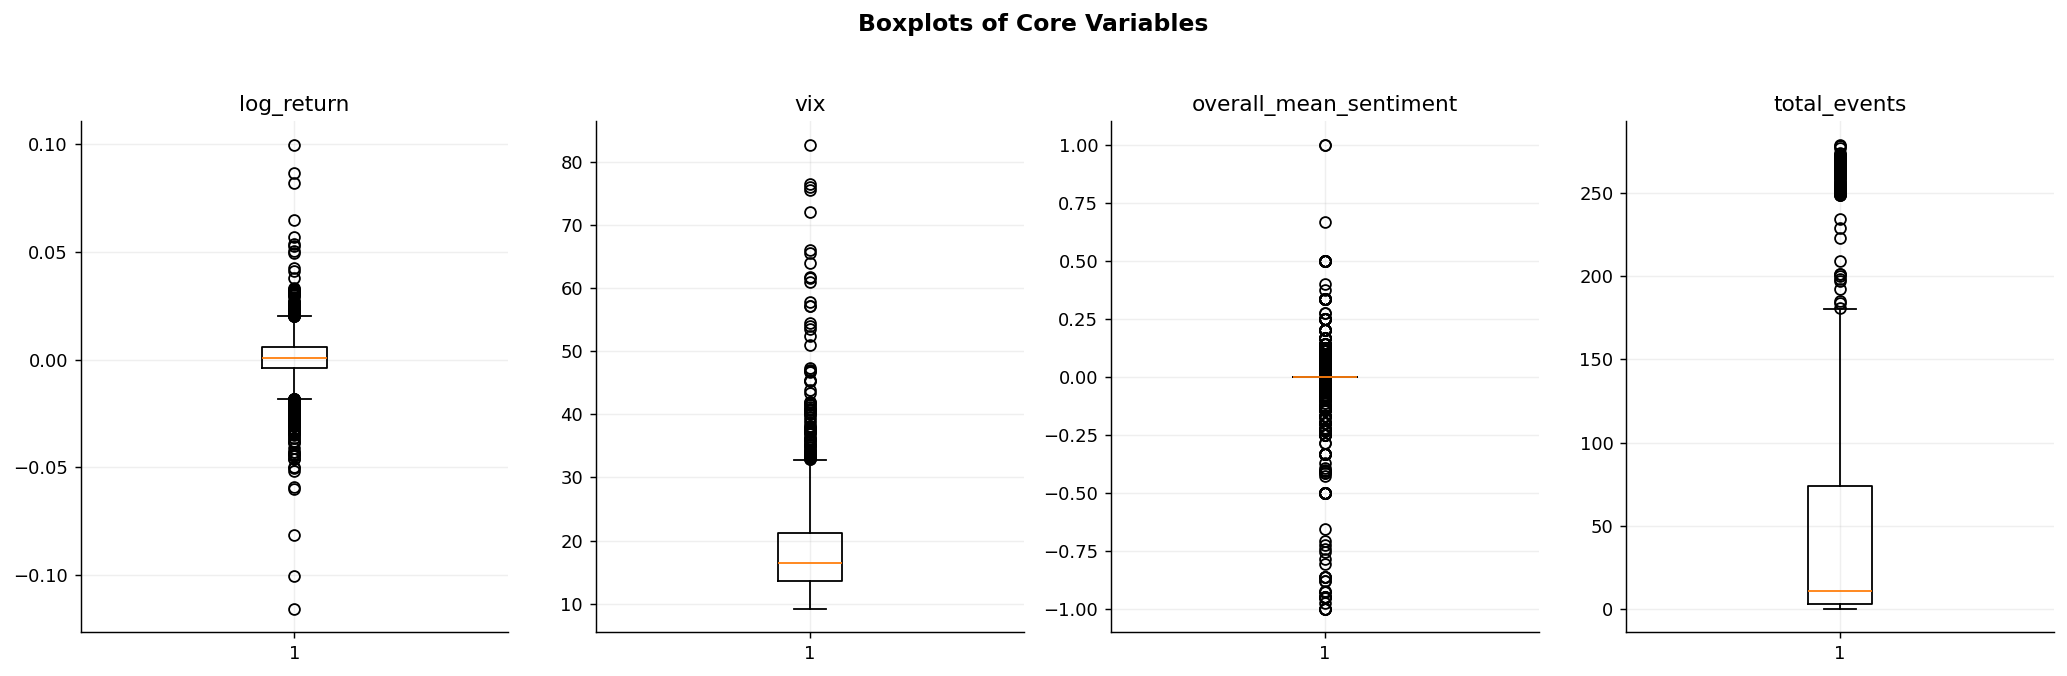

Saved figure → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02o_boxplots.png


In [63]:
box_vars = ["log_return", "vix", "overall_mean_sentiment", "total_events"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, box_vars):
    ax.boxplot(master_df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.grid(alpha=0.2)

fig.suptitle("Boxplots of Core Variables", y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout()

output_path = FIG_DIR / "02o_boxplots.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure → {output_path}")

**Figure 02o** — The boxplots show several extreme observations in `log_return`, `vix`, `overall_mean_sentiment`, and `total_events`. These are not treated as data errors. In the context of this project, extreme market moves and event clusters are substantively meaningful because they may represent precisely the types of market reactions the study aims to analyse. Therefore, the observations are retained rather than removed or winsorised.

### 02p — Rolling statistics

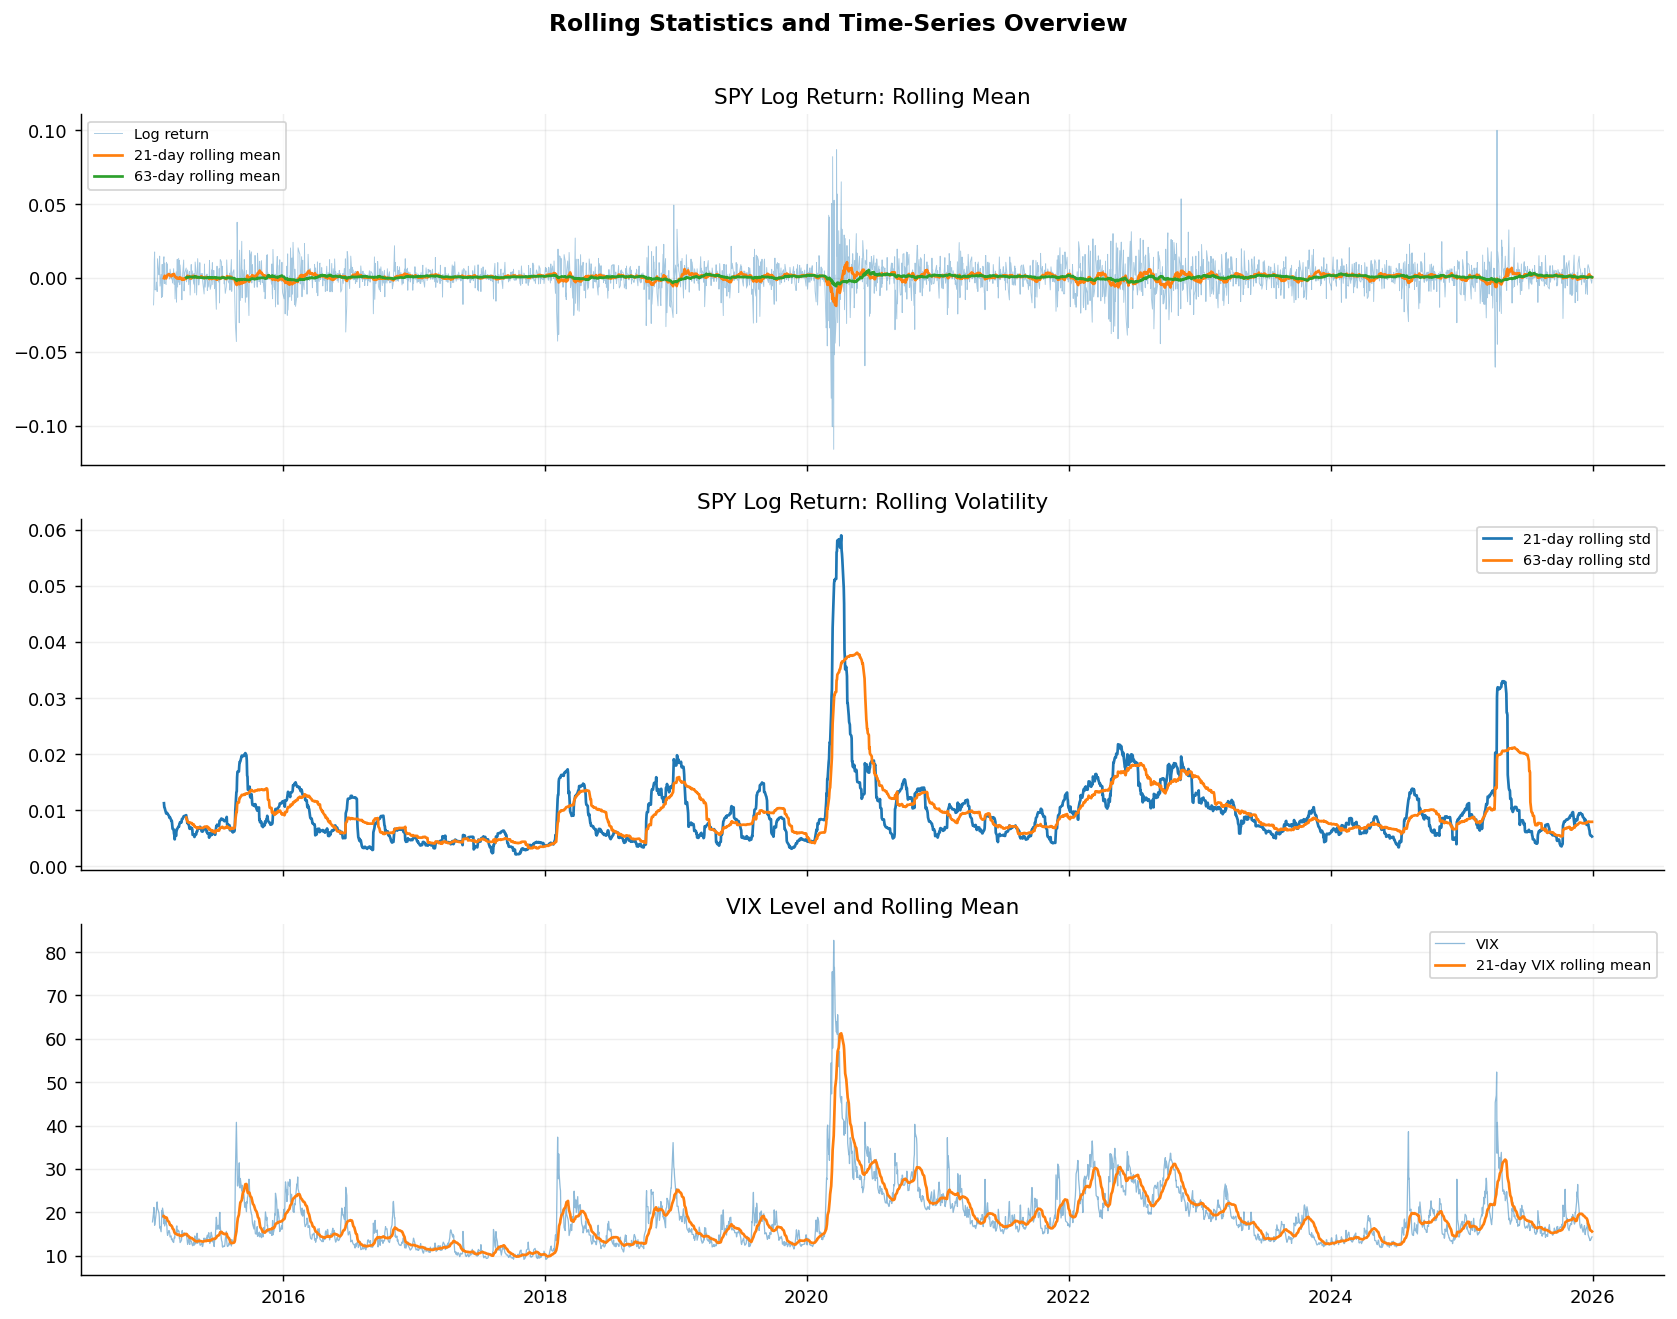

Saved figure → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02p_rolling_stationarity.png


In [64]:
plot_df = master_df.copy()

plot_df["roll_mean_21"] = plot_df["log_return"].rolling(21).mean()
plot_df["roll_std_21"] = plot_df["log_return"].rolling(21).std()
plot_df["roll_mean_63"] = plot_df["log_return"].rolling(63).mean()
plot_df["roll_std_63"] = plot_df["log_return"].rolling(63).std()
plot_df["vix_roll_mean_21"] = plot_df["vix"].rolling(21).mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(plot_df["date"], plot_df["log_return"], alpha=0.4, linewidth=0.5, label="Log return")
axes[0].plot(plot_df["date"], plot_df["roll_mean_21"], label="21-day rolling mean")
axes[0].plot(plot_df["date"], plot_df["roll_mean_63"], label="63-day rolling mean")
axes[0].set_title("SPY Log Return: Rolling Mean")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

axes[1].plot(plot_df["date"], plot_df["roll_std_21"], label="21-day rolling std")
axes[1].plot(plot_df["date"], plot_df["roll_std_63"], label="63-day rolling std")
axes[1].set_title("SPY Log Return: Rolling Volatility")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

axes[2].plot(plot_df["date"], plot_df["vix"], alpha=0.5, linewidth=0.7, label="VIX")
axes[2].plot(plot_df["date"], plot_df["vix_roll_mean_21"], label="21-day VIX rolling mean")
axes[2].set_title("VIX Level and Rolling Mean")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)

fig.suptitle("Rolling Statistics and Time-Series Overview", y=1.01, fontsize=13, fontweight="bold")
fig.tight_layout()

output_path = FIG_DIR / "02p_rolling_stationarity.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure → {output_path}")

**Figure 02p** — The rolling mean of `log_return` remains close to zero across the sample period, which is consistent with the stationarity result reported earlier. However, rolling volatility varies substantially over time, with clear volatility clustering around major stress periods such as the 2020 COVID-19 shock, the 2022 monetary tightening period, and a smaller increase around 2025. The VIX panel shows similar regime behaviour, supporting the inclusion of volatility-based features in later modelling.

### 02q — ACF/PACF

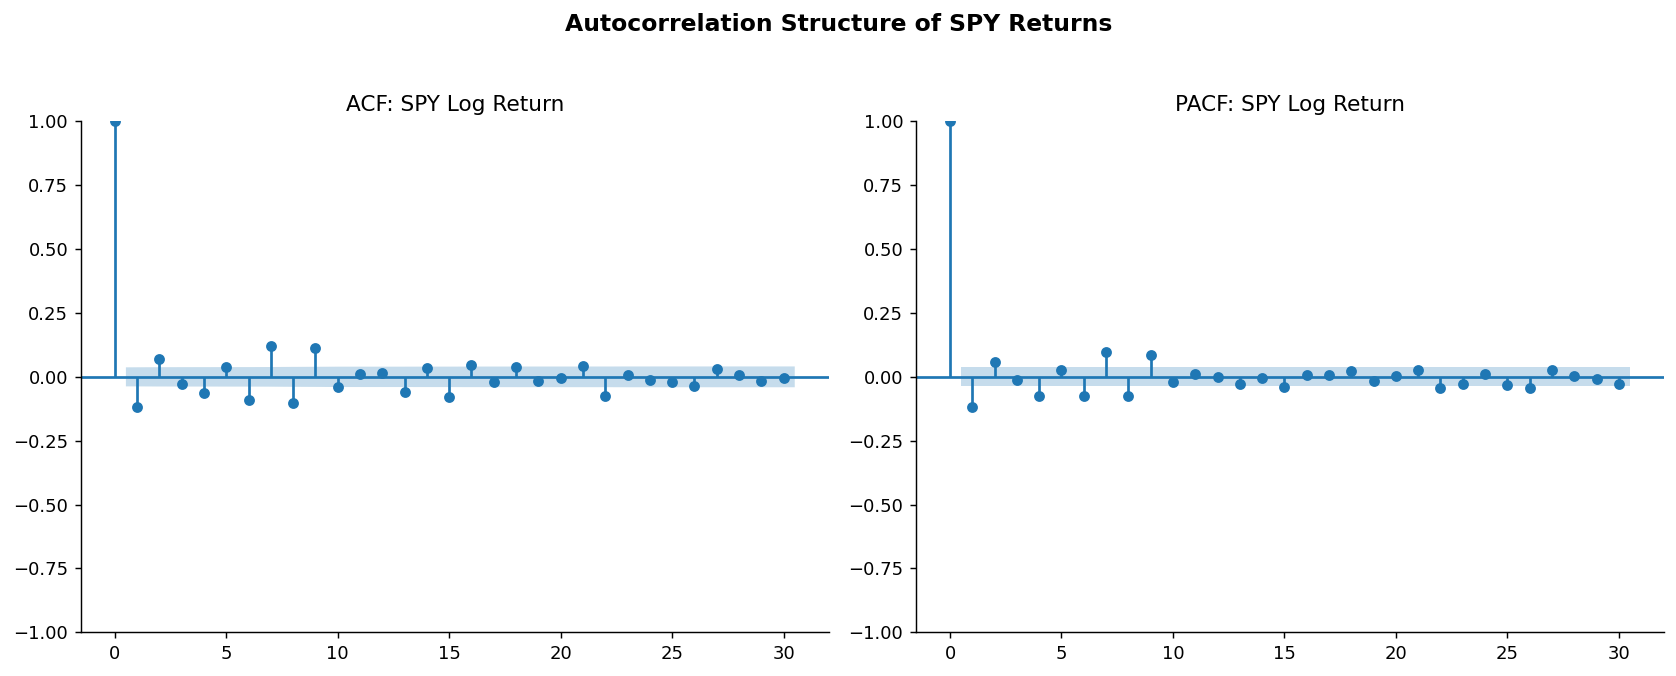

Saved figure → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02q_acf_pacf.png


In [66]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_acf(master_df["log_return"].dropna(), lags=30, ax=axes[0])
axes[0].set_title("ACF: SPY Log Return")

plot_pacf(master_df["log_return"].dropna(), lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF: SPY Log Return")

fig.suptitle("Autocorrelation Structure of SPY Returns", y=1.03, fontsize=13, fontweight="bold")
fig.tight_layout()

output_path = FIG_DIR / "02q_acf_pacf.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure → {output_path}")

**Figure 02q** — The ACF and PACF plots show weak autocorrelation in SPY daily log returns, with most lag values remaining within the confidence bands after the first few lags. This pattern is consistent with the near-efficient behaviour of daily equity returns, where strong linear predictability is limited. The result supports the use of short lag features while avoiding excessive lag expansion that could add noise and increase overfitting risk.

### 02r — Correlation heatmap

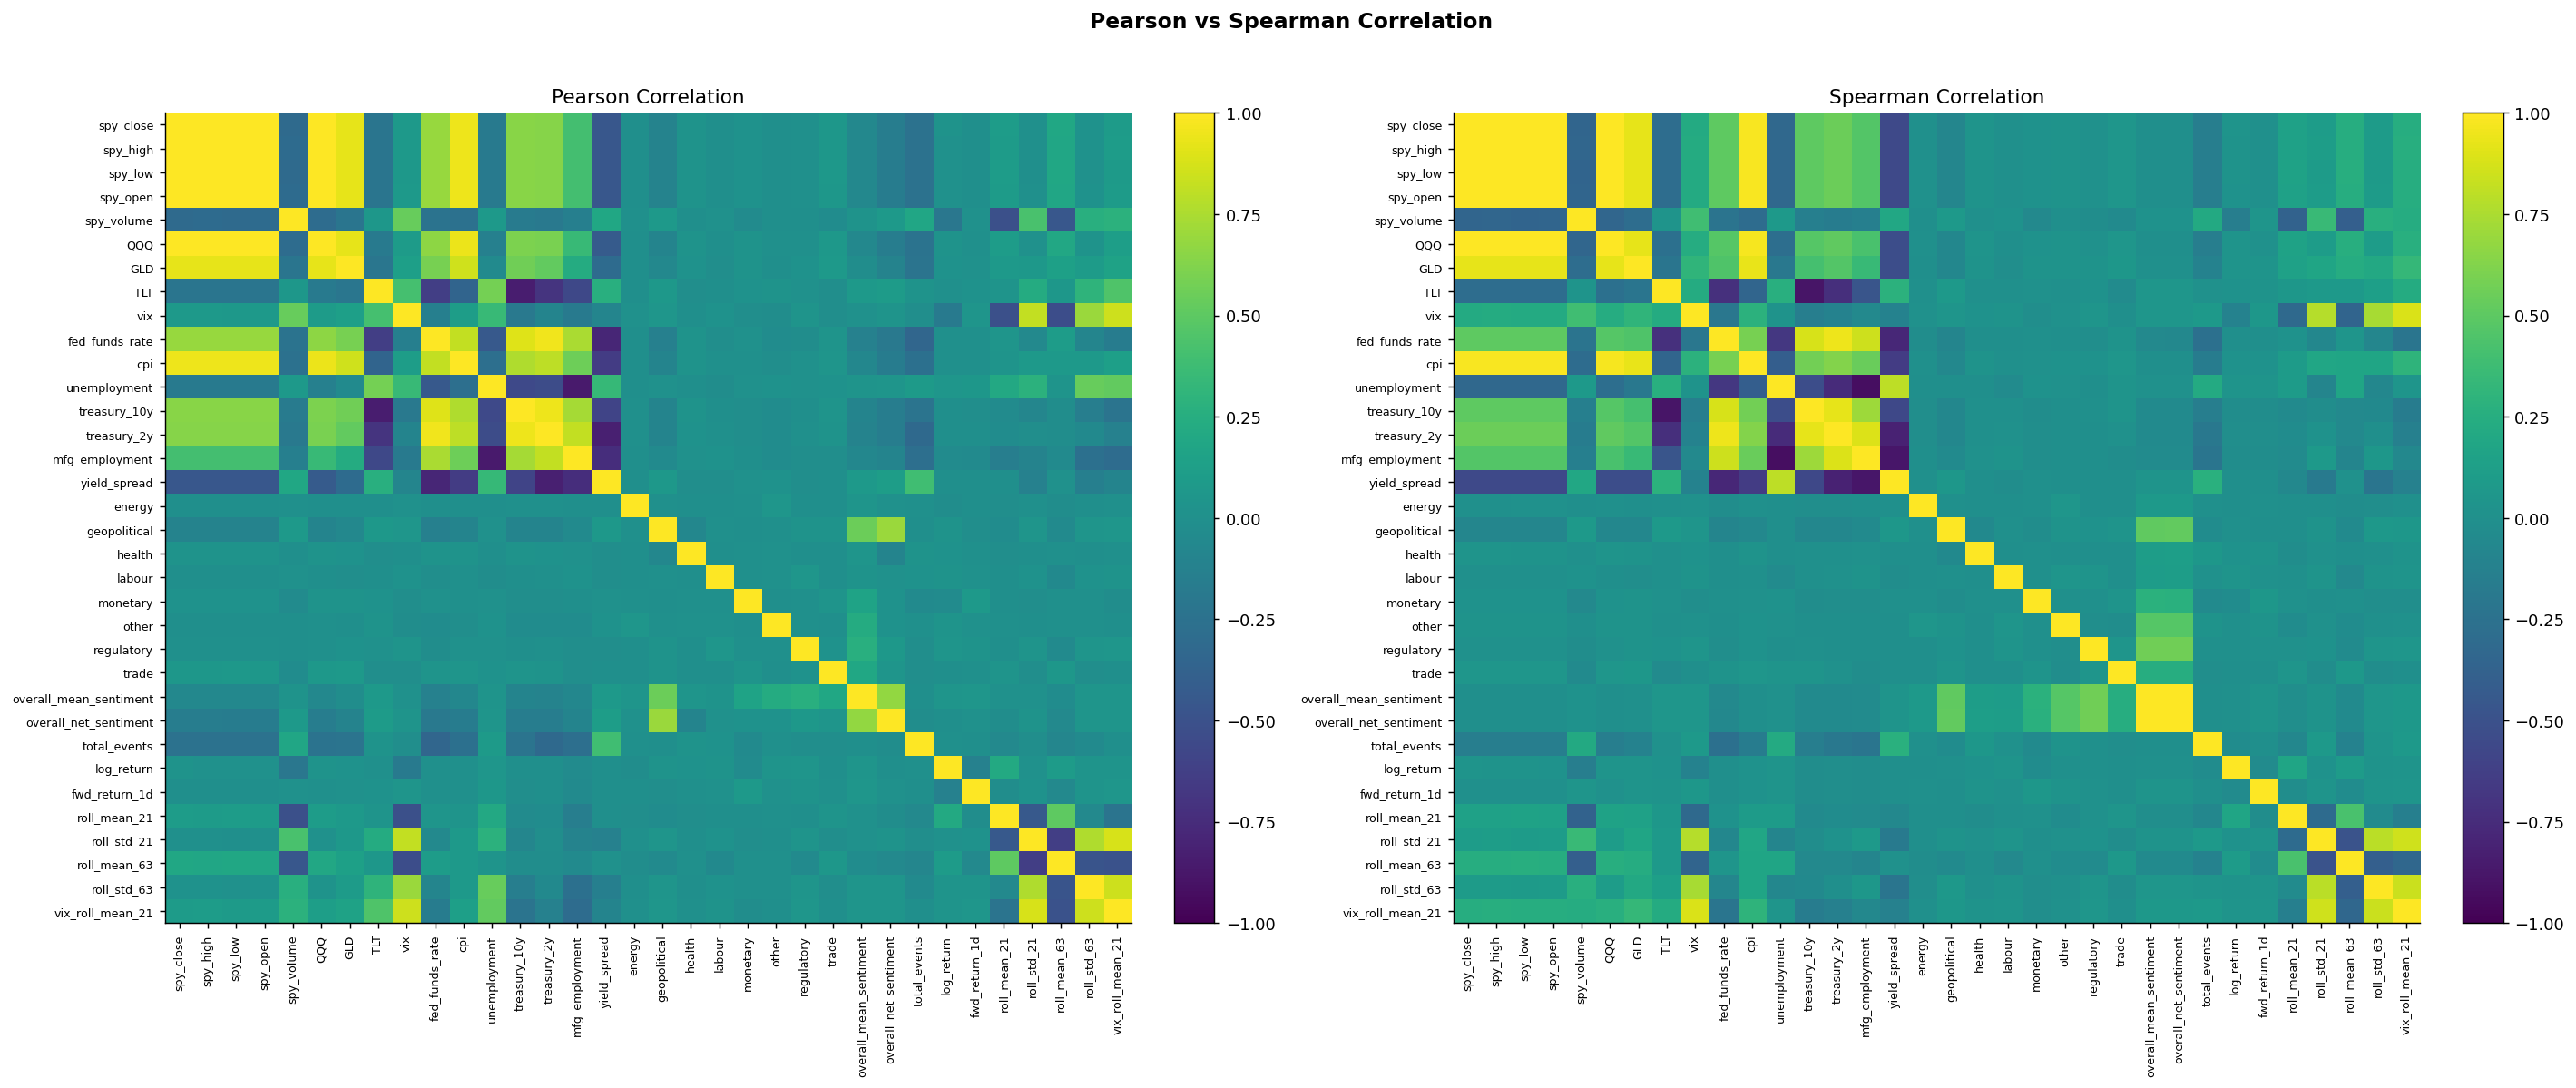

Saved figure → /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI/reports/figures/02r_correlation_heatmap.png


In [67]:
plot_cols = [
    c for c in master_df.columns
    if c not in ("date", "split")
    and pd.api.types.is_numeric_dtype(master_df[c])
]

plot_cols = [
    c for c in plot_cols
    if not np.isclose(master_df[c].std(skipna=True), 0)
]

sub = master_df[plot_cols]

pearson_full = sub.corr(method="pearson")
spearman_full = sub.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

im1 = axes[0].imshow(pearson_full, vmin=-1, vmax=1, aspect="auto")
axes[0].set_title("Pearson Correlation")
axes[0].set_xticks(range(len(plot_cols)))
axes[0].set_yticks(range(len(plot_cols)))
axes[0].set_xticklabels(plot_cols, rotation=90, fontsize=7)
axes[0].set_yticklabels(plot_cols, fontsize=7)
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(spearman_full, vmin=-1, vmax=1, aspect="auto")
axes[1].set_title("Spearman Correlation")
axes[1].set_xticks(range(len(plot_cols)))
axes[1].set_yticks(range(len(plot_cols)))
axes[1].set_xticklabels(plot_cols, rotation=90, fontsize=7)
axes[1].set_yticklabels(plot_cols, fontsize=7)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle("Pearson vs Spearman Correlation", y=1.02, fontsize=13, fontweight="bold")
fig.tight_layout()

output_path = FIG_DIR / "02r_correlation_heatmap.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved figure → {output_path}")

**Figure 02r** — The Pearson and Spearman heatmaps show broadly similar correlation structure for the continuous market and macroeconomic variables. Strong correlations appear among price-level variables, especially SPY OHLC prices and QQQ, which is expected because these series describe closely related equity-market movements. Some high correlations involving CPI and price levels should be interpreted cautiously because they are likely driven by shared non-stationary trends rather than direct predictive relationships. For zero-inflated event and sentiment variables, Spearman correlation is more informative than Pearson because many observations are tied at zero.

## 9.6 Section Summary — EDA Implementation

The visual analysis confirms the key statistical patterns identified in the numerical tests. SPY daily log returns are centred close to zero but display heavy-tailed behaviour, while SPY price levels are trending and non-stationary. The VIX is strongly right-skewed and shows regime-like volatility spikes, reinforcing the importance of volatility features in later modelling.

The QQ plots and boxplots confirm that normality assumptions should be treated cautiously. Extreme observations are retained because they are meaningful market events rather than simple data errors. Rolling statistics show that return volatility changes over time, while ACF and PACF plots suggest limited linear autocorrelation in daily returns.

The correlation heatmaps highlight expected multicollinearity among related market variables, especially OHLC prices and broad equity indices. They also show that raw correlations involving non-stationary price and macroeconomic levels should not be interpreted as causal or predictive relationships. Overall, the EDA supports the project’s modelling strategy: use returns, transformed variables, volatility measures, and carefully controlled feature selection rather than relying on raw price or macroeconomic levels.